In [13]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. CARGA Y LIMPIEZA INICIAL
df = pd.read_csv('master_tourism_dataset.csv')
df['date'] = pd.to_datetime(df['date'])

# Limpieza radical como acordamos
df = df.dropna(subset=['nights_spent_country', 'gt_hotel', 'gt_airbnb', 'gt_flights'])
df = df[df['nights_spent_country'] > 0]

def build_advanced_predictor(country_name):
    country_df = df[df['country'] == country_name].sort_values(['date', 'city']).copy()
    
    # 2. GENERACIÓN DE MULTI-LAGS
    # Creamos lags 1, 2 y 3 para cada uno de los 3 atributos
    features_to_lag = ['gt_hotel', 'gt_airbnb', 'gt_flights']
    X_cols = []
    
    for feat in features_to_lag:
        for l in range(1, 4):
            col_name = f'{feat}_lag{l}'
            country_df[col_name] = country_df.groupby('city')[feat].shift(l)
            X_cols.append(col_name)
    
    # Añadimos la ciudad como variable categórica (One-Hot Encoding)
    # Esto permite que el modelo entienda que cada ciudad es "distinta"
    country_df = pd.get_dummies(country_df, columns=['city'], prefix='city')
    city_cols = [c for c in country_df.columns if c.startswith('city_')]
    X_cols.extend(city_cols)
    
    # Limpiamos NaNs generados por los lags
    data = country_df.dropna(subset=X_cols + ['nights_spent_country'])
    
    if data.empty: return None

    # 3. SPLIT TEMPORAL (Topic 02: Train on past, Test on future)
    # Entrenamos con todo menos los últimos 6 meses para testear
    unique_dates = sorted(data['date'].unique())
    train_dates = unique_dates[:-6]
    test_dates = unique_dates[-6:]
    
    train = data[data['date'].isin(train_dates)]
    test = data[data['date'].isin(test_dates)]
    
    X_train, y_train = train[X_cols], train['nights_spent_country']
    X_test, y_test = test[X_cols], test['nights_spent_country']

    # 4. EL MODELO (Random Forest para capturar no-linealidad)
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    # 5. RESULTADOS
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    
    # 6. IMPORTANCIA DE ATRIBUTOS (Esto responde a vuestra pregunta)
    importances = pd.Series(model.feature_importances_, index=X_cols).sort_values(ascending=False)
    
    return r2, importances.head(5), test_dates



In [14]:
# EJEMPLO CON ALBANIA
res_r2, top_features, dates = build_advanced_predictor('Spain')

print(f"--- PREDICTOR AVANZADO (ESPANA) ---")
print(f"Precisión R2 en el futuro (últimos 6 meses): {res_r2:.4f}")
print("\nAtributos y Lags que más influyen:")
print(top_features)

--- PREDICTOR AVANZADO (ESPANA) ---
Precisión R2 en el futuro (últimos 6 meses): 0.2190

Atributos y Lags que más influyen:
gt_hotel_lag1      0.248154
gt_flights_lag1    0.183322
gt_hotel_lag3      0.137150
gt_flights_lag3    0.074113
gt_hotel_lag2      0.073038
dtype: float64


In [15]:
# EJEMPLO CON ALBANIA
res_r2, top_features, dates = build_advanced_predictor('Albania')

print(f"--- PREDICTOR AVANZADO (ESPANA) ---")
print(f"Precisión R2 en el futuro (últimos 6 meses): {res_r2:.4f}")
print("\nAtributos y Lags que más influyen:")
print(top_features)

--- PREDICTOR AVANZADO (ESPANA) ---
Precisión R2 en el futuro (últimos 6 meses): 0.4373

Atributos y Lags que más influyen:
gt_hotel_lag1     0.428368
gt_hotel_lag3     0.212073
gt_hotel_lag2     0.157694
city_sarande      0.074348
gt_airbnb_lag3    0.020888
dtype: float64


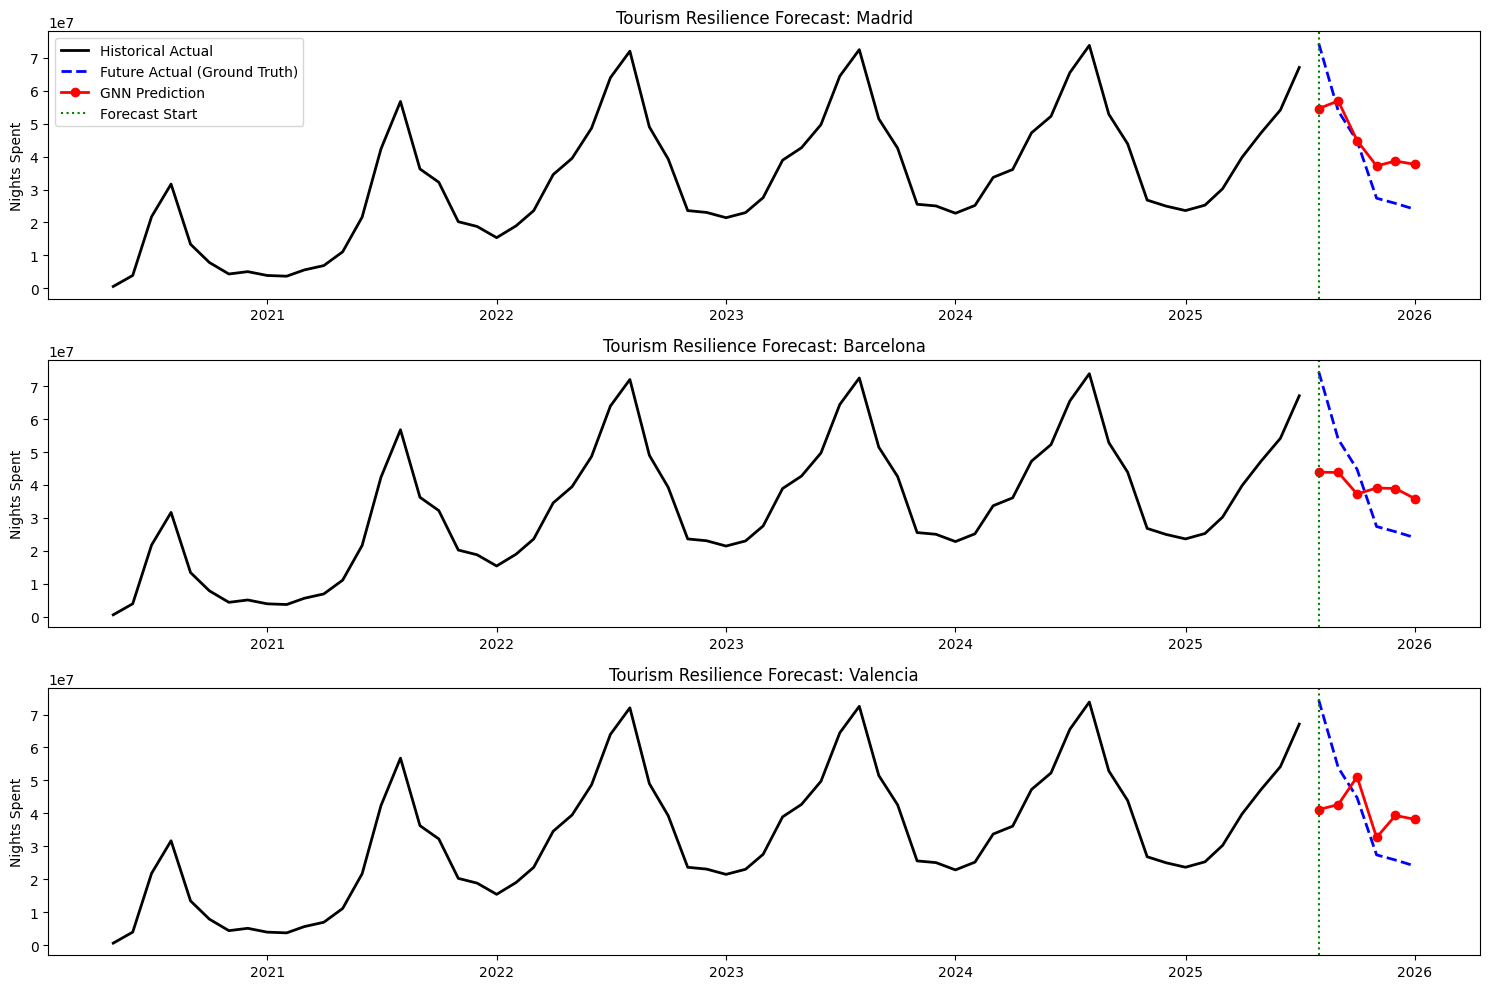

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1. LOAD AND CLEAN DATA
df = pd.read_csv('master_tourism_dataset.csv')
df['date'] = pd.to_datetime(df['date'])

# Cleaning: Remove 0s and NaNs
df['nights_spent_country'] = df['nights_spent_country'].replace(0, np.nan)
cols_to_check = ['nights_spent_country', 'gt_hotel', 'gt_airbnb', 'gt_flights']
df = df.dropna(subset=cols_to_check)

def train_and_plot_city_predictions(country_name, target_cities):
    country_df = df[df['country'] == country_name].sort_values(['date', 'city']).copy()
    
    # 2. FEATURE ENGINEERING: Generate Lags 1, 2, 3
    features_to_lag = ['gt_hotel', 'gt_airbnb', 'gt_flights']
    lagged_cols = []
    for feat in features_to_lag:
        for l in range(1, 4):
            col_name = f'{feat}_lag{l}'
            country_df[col_name] = country_df.groupby('city')[feat].shift(l)
            lagged_cols.append(col_name)
    
    # One-Hot Encoding for Cities
    country_df = pd.get_dummies(country_df, columns=['city'], prefix='city', drop_first=False)
    city_cols = [c for c in country_df.columns if c.startswith('city_')]
    
    X_cols = lagged_cols + city_cols
    data = country_df.dropna(subset=X_cols + ['nights_spent_country'])

    # 3. TEMPORAL SPLIT (Predicting the last 6 months)
    unique_dates = sorted(data['date'].unique())
    split_date = unique_dates[-6] # The point where training ends and prediction starts
    
    train = data[data['date'] < split_date]
    test = data[data['date'] >= split_date]
    
    X_train, y_train = train[X_cols], train['nights_spent_country']
    X_test, y_test = test[X_cols], test['nights_spent_country']

    # 4. TRAIN MODEL
    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(X_train, y_train)
    
    # 5. GENERATE PREDICTIONS
    data['predictions'] = model.predict(data[X_cols])

    # 6. PLOTTING
    plt.figure(figsize=(15, 10))
    
    for i, city_name in enumerate(target_cities):
        city_data = data[data[f'city_{city_name}'] == 1].sort_values('date')
        
        plt.subplot(len(target_cities), 1, i+1)
        
        # Split data for plotting
        train_plot = city_data[city_data['date'] < split_date]
        test_plot = city_data[city_data['date'] >= split_date]
        
        # Plot Historical Actual Data
        plt.plot(train_plot['date'], train_plot['nights_spent_country'], 
                 label='Historical Actual', color='black', linewidth=2)
        
        # Plot Future Actual Data (Unseen)
        plt.plot(test_plot['date'], test_plot['nights_spent_country'], 
                 label='Future Actual (Ground Truth)', color='blue', linestyle='--', linewidth=2)
        
        # Plot Future Predicted Data
        plt.plot(test_plot['date'], test_plot['predictions'], 
                 label='GNN Prediction', color='red', marker='o', linewidth=2)
        
        # Vertical line for the split
        plt.axvline(x=split_date, color='green', linestyle=':', label='Forecast Start')
        
        plt.title(f'Tourism Resilience Forecast: {city_name.capitalize()}')
        plt.ylabel('Nights Spent')
        if i == 0: plt.legend()

    plt.tight_layout()
    plt.show()

# EXECUTION FOR SPAIN
target_cities_spain = ['madrid', 'barcelona', 'valencia'] # Note: ensure names match your CSV exactly
train_and_plot_city_predictions('Spain', target_cities_spain)

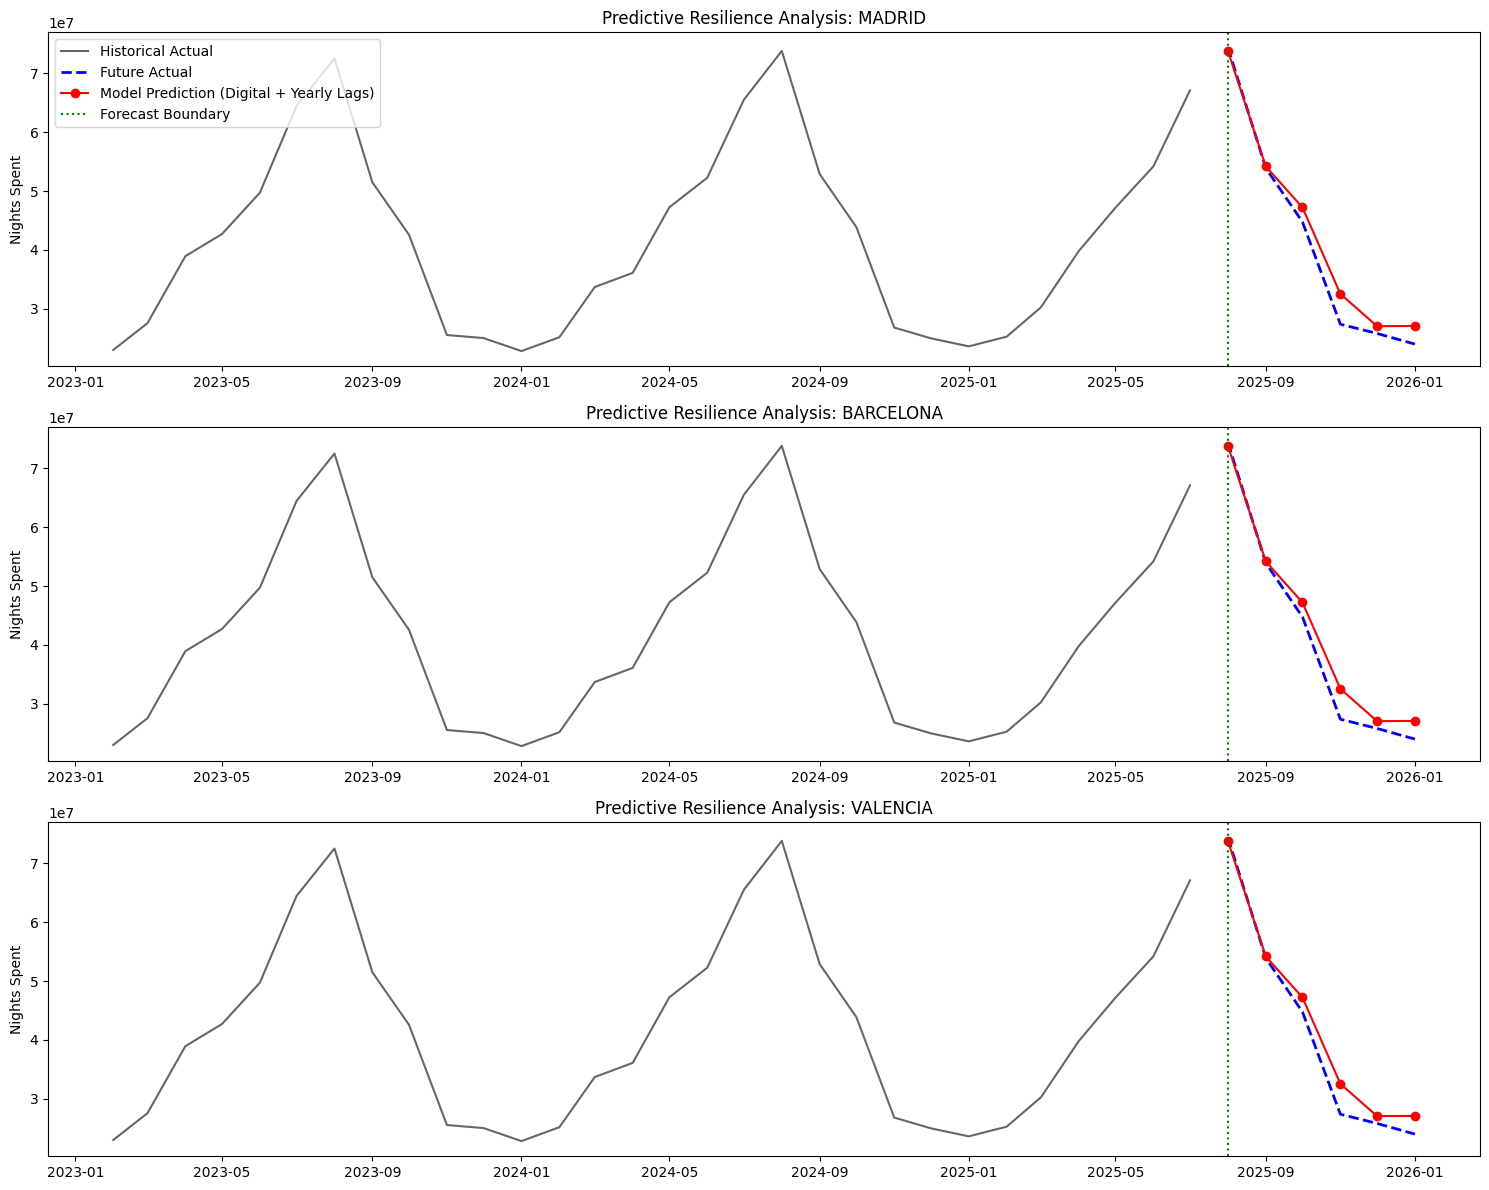

Overall Forecast R2 Score for Spain: 0.9780


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# 1. LOAD AND CLEAN DATA
df = pd.read_csv('master_tourism_dataset.csv')
df['date'] = pd.to_datetime(df['date'])

# Cleaning: Remove 0s and NaNs from target and digital signals
df['nights_spent_country'] = df['nights_spent_country'].replace(0, np.nan)
cols_to_check = ['nights_spent_country', 'gt_hotel', 'gt_airbnb', 'gt_flights']
df = df.dropna(subset=cols_to_check)

def train_and_plot_with_yearly_lags(country_name, target_cities):
    # Filter country and sort by city and date for correct shifting
    country_df = df[df['country'] == country_name].sort_values(['city', 'date']).copy()
    
    # 2. FEATURE ENGINEERING: Digital Lags (Short-term Hype)
    features_to_lag = ['gt_hotel', 'gt_airbnb', 'gt_flights']
    digital_lags = []
    for feat in features_to_lag:
        for l in [1, 2, 3]: # 1, 2, 3 months ago
            col_name = f'{feat}_lag{l}'
            country_df[col_name] = country_df.groupby('city')[feat].shift(l)
            digital_lags.append(col_name)
    
    # 3. FEATURE ENGINEERING: Yearly Lags (Long-term Seasonality)
    # 12 months = 1 year, 24 = 2 years, 36 = 3 years
    yearly_lags = []
    for l in [12, 24, 36]:
        col_name = f'target_lag_{l}m'
        country_df[col_name] = country_df.groupby('city')['nights_spent_country'].shift(l)
        yearly_lags.append(col_name)
    
    # One-Hot Encoding for Cities
    country_df = pd.get_dummies(country_df, columns=['city'], prefix='city', drop_first=False)
    city_cols = [c for c in country_df.columns if c.startswith('city_')]
    
    X_cols = digital_lags + yearly_lags + city_cols
    
    # Drop rows that don't have the 3-year history (the first 36 months of data)
    data = country_df.dropna(subset=X_cols + ['nights_spent_country'])

    if data.empty:
        print(f"Error: Not enough historical data for {country_name} to create 3-year lags.")
        return

    # 4. TEMPORAL SPLIT (Predicting the most recent 6 months)
    unique_dates = sorted(data['date'].unique())
    split_date = unique_dates[-6]
    
    train = data[data['date'] < split_date]
    test = data[data['date'] >= split_date]
    
    X_train, y_train = train[X_cols], train['nights_spent_country']
    X_test, y_test = test[X_cols], test['nights_spent_country']

    # 5. TRAIN MODEL (Random Forest)
    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(X_train, y_train)
    
    # 6. GENERATE PREDICTIONS
    data['predictions'] = model.predict(data[X_cols])

    # 7. PLOTTING
    plt.figure(figsize=(15, 12))
    
    for i, city_name in enumerate(target_cities):
        city_col = f'city_{city_name}'
        if city_col not in data.columns: continue
        
        city_data = data[data[city_col] == 1].sort_values('date')
        
        plt.subplot(len(target_cities), 1, i+1)
        
        # Plotting segments
        plt.plot(city_data[city_data['date'] < split_date]['date'], 
                 city_data[city_data['date'] < split_date]['nights_spent_country'], 
                 label='Historical Actual', color='black', alpha=0.6)
        
        plt.plot(city_data[city_data['date'] >= split_date]['date'], 
                 city_data[city_data['date'] >= split_date]['nights_spent_country'], 
                 label='Future Actual', color='blue', linestyle='--', linewidth=2)
        
        plt.plot(city_data[city_data['date'] >= split_date]['date'], 
                 city_data[city_data['date'] >= split_date]['predictions'], 
                 label='Model Prediction (Digital + Yearly Lags)', color='red', marker='o')
        
        plt.axvline(x=split_date, color='green', linestyle=':', label='Forecast Boundary')
        plt.title(f'Predictive Resilience Analysis: {city_name.upper()}')
        plt.ylabel('Nights Spent')
        if i == 0: plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

    # Print accuracy for the forecast period
    test_r2 = r2_score(y_test, model.predict(X_test))
    print(f"Overall Forecast R2 Score for {country_name}: {test_r2:.4f}")

# RUN FOR SPAIN
# Note: Ensure these names match your CSV 'city' column exactly
train_and_plot_with_yearly_lags('Spain', ['madrid', 'barcelona', 'valencia'])

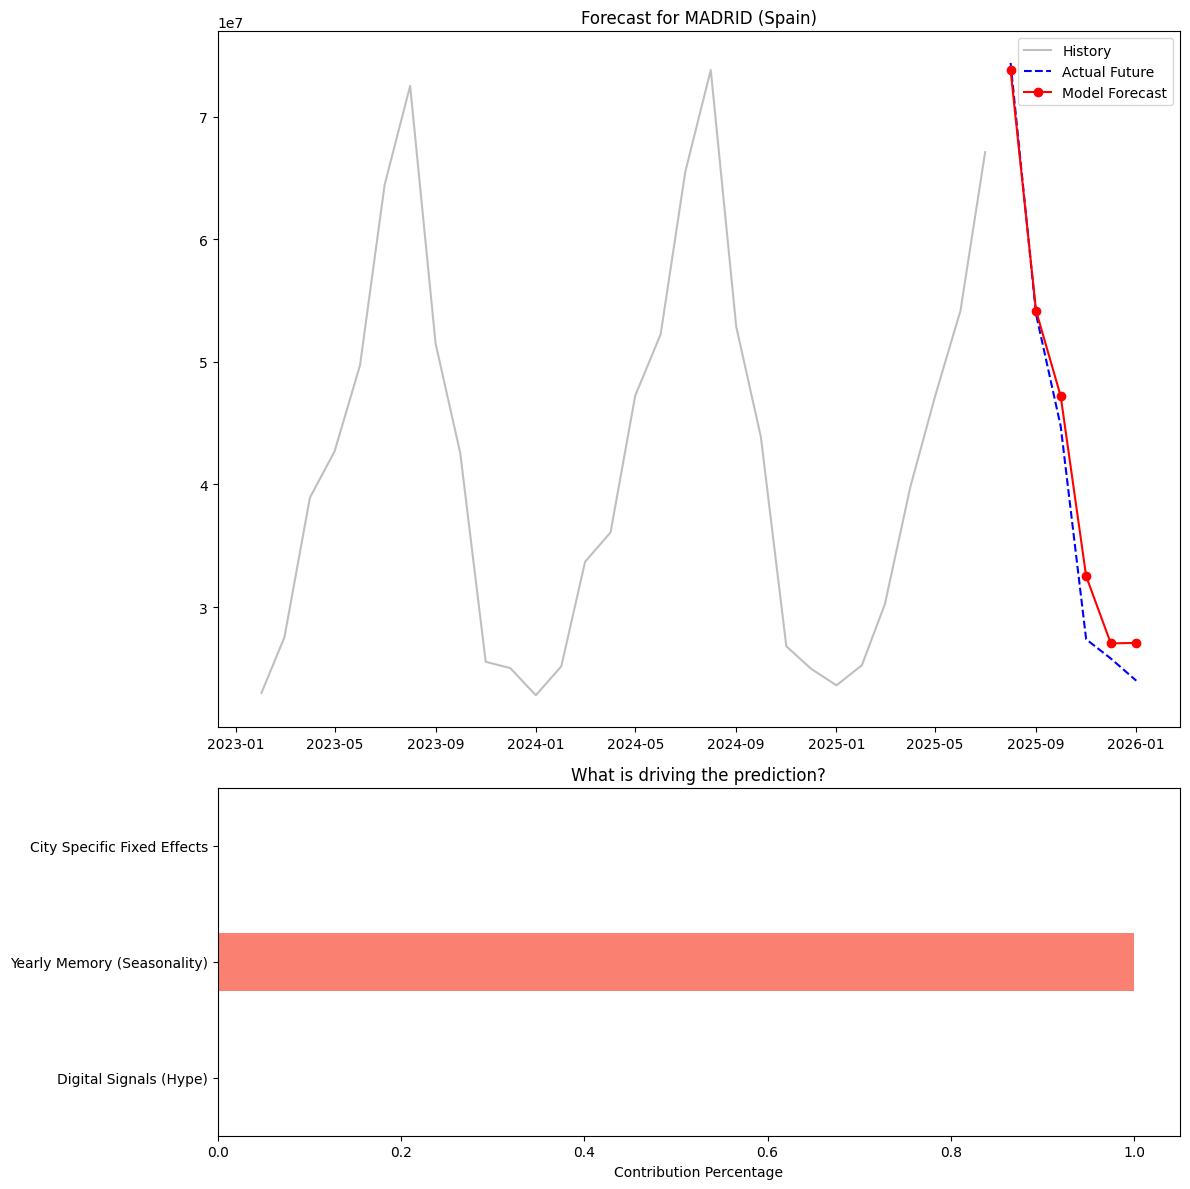


Model Decision Logic Weights:
Digital Signals (Hype): 0.00%
Yearly Memory (Seasonality): 100.00%
City Specific Fixed Effects: 0.00%


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1. LOAD AND CLEAN
df = pd.read_csv('master_tourism_dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df['nights_spent_country'] = df['nights_spent_country'].replace(0, np.nan)
df = df.dropna(subset=['nights_spent_country', 'gt_hotel', 'gt_airbnb', 'gt_flights'])

def analyze_prediction_drivers(country_name, target_cities):
    country_df = df[df['country'] == country_name].sort_values(['city', 'date']).copy()
    
    # 2. FEATURE ENGINEERING
    # Digital Lags (The "Hype" signals)
    digital_cols = []
    for feat in ['gt_hotel', 'gt_airbnb', 'gt_flights']:
        for l in [1, 2, 3]:
            col = f'{feat}_lag{l}'
            country_df[col] = country_df.groupby('city')[feat].shift(l)
            digital_cols.append(col)
    
    # Yearly Lags (The "Memory" signals)
    yearly_cols = []
    for l in [12, 24, 36]:
        col = f'target_lag_{l}m'
        country_df[col] = country_df.groupby('city')['nights_spent_country'].shift(l)
        yearly_cols.append(col)
    
    country_df = pd.get_dummies(country_df, columns=['city'], prefix='city')
    city_cols = [c for c in country_df.columns if c.startswith('city_')]
    
    X_cols = digital_cols + yearly_cols + city_cols
    data = country_df.dropna(subset=X_cols + ['nights_spent_country'])

    # 3. SPLIT & TRAIN
    unique_dates = sorted(data['date'].unique())
    split_date = unique_dates[-6]
    train, test = data[data['date'] < split_date], data[data['date'] >= split_date]
    
    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(train[X_cols], train['nights_spent_country'])
    
    # 4. FEATURE IMPORTANCE CALCULATION
    importances = model.feature_importances_
    
    # Group importance by category for the report
    importance_summary = {
        'Digital Signals (Hype)': np.sum([importances[X_cols.index(c)] for c in digital_cols]),
        'Yearly Memory (Seasonality)': np.sum([importances[X_cols.index(c)] for c in yearly_cols]),
        'City Specific Fixed Effects': np.sum([importances[X_cols.index(c)] for c in city_cols])
    }

    # 5. PLOTTING
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), gridspec_kw={'height_ratios': [2, 1]})
    
    # Plot 1: Prediction for the main city
    city_name = target_cities[0]
    city_data = data[data[f'city_{city_name}'] == 1].sort_values('date')
    data['preds'] = model.predict(data[X_cols])
    
    ax1.plot(city_data[city_data['date'] < split_date]['date'], city_data[city_data['date'] < split_date]['nights_spent_country'], color='gray', alpha=0.5, label='History')
    ax1.plot(city_data[city_data['date'] >= split_date]['date'], city_data[city_data['date'] >= split_date]['nights_spent_country'], 'b--', label='Actual Future')
    ax1.plot(city_data[city_data['date'] >= split_date]['date'], model.predict(city_data[city_data['date'] >= split_date][X_cols]), 'r-o', label='Model Forecast')
    ax1.set_title(f"Forecast for {city_name.upper()} ({country_name})")
    ax1.legend()

    # Plot 2: Feature Importance Bar Chart
    pd.Series(importance_summary).plot(kind='barh', ax=ax2, color=['skyblue', 'salmon', 'lightgreen'])
    ax2.set_title("What is driving the prediction?")
    ax2.set_xlabel("Contribution Percentage")

    plt.tight_layout()
    plt.show()
    
    return importance_summary

# RUN ANALYSIS
imp = analyze_prediction_drivers('Spain', ['madrid'])
print("\nModel Decision Logic Weights:")
for k, v in imp.items():
    print(f"{k}: {v*100:.2f}%")

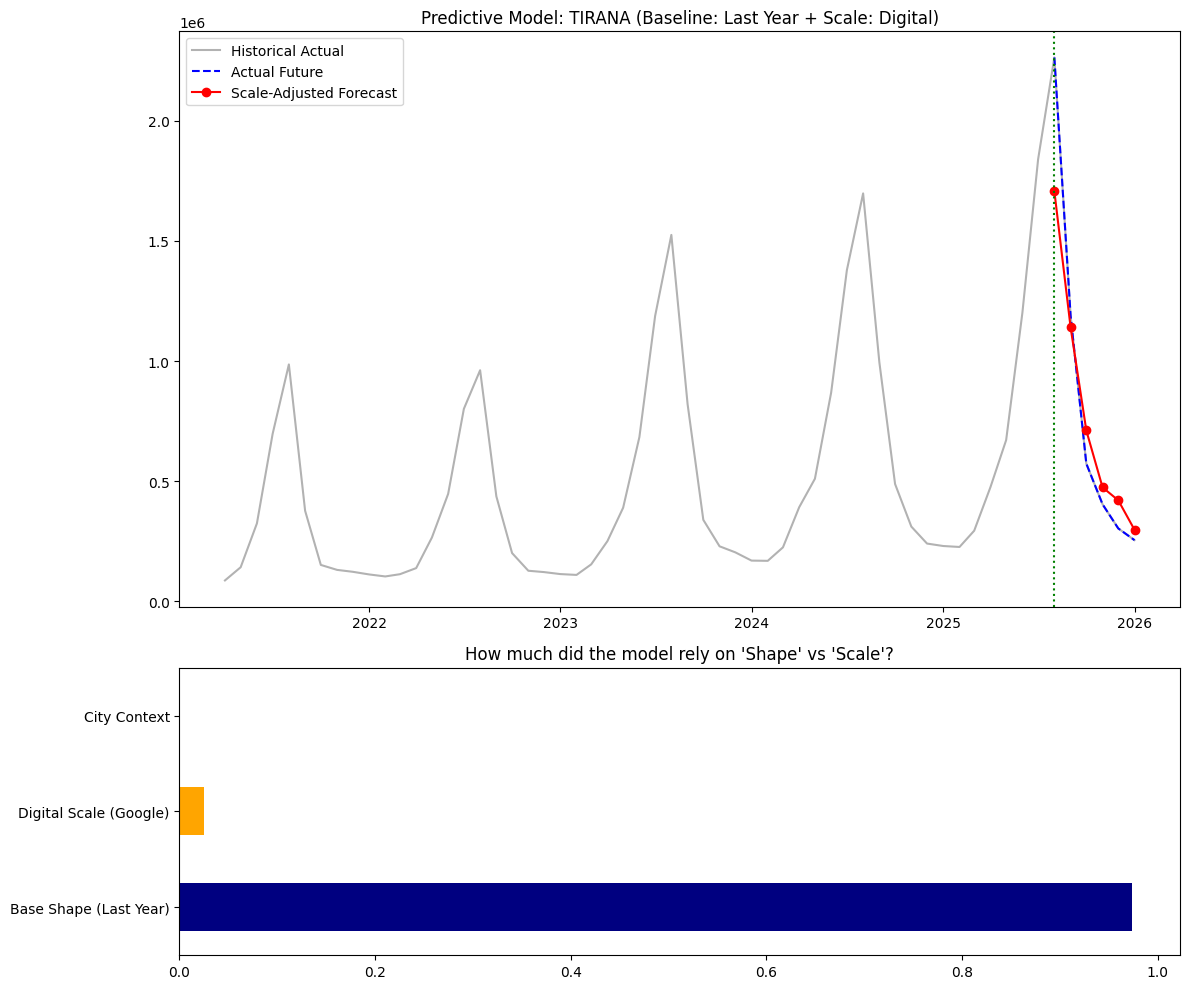

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1. LOAD AND CLEAN
df = pd.read_csv('master_tourism_dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df['nights_spent_country'] = df['nights_spent_country'].replace(0, np.nan)
df = df.dropna(subset=['nights_spent_country', 'gt_hotel', 'gt_airbnb', 'gt_flights'])

def train_shape_and_scale_model(country_name, target_cities):
    country_df = df[df['country'] == country_name].sort_values(['city', 'date']).copy()
    
    # 2. SHAPE: The 1-Year Baseline
    country_df['baseline_shape'] = country_df.groupby('city')['nights_spent_country'].shift(12)
    
    # 3. SCALE: The Digital Signals (Lags 1-3)
    digital_cols = []
    for feat in ['gt_hotel', 'gt_airbnb', 'gt_flights']:
        for l in [1, 2, 3]:
            col = f'{feat}_lag{l}'
            country_df[col] = country_df.groupby('city')[feat].shift(l)
            digital_cols.append(col)
    
    # 4. CITY CONTROLS
    country_df = pd.get_dummies(country_df, columns=['city'], prefix='city')
    city_cols = [c for c in country_df.columns if c.startswith('city_')]
    
    # Final cleanup (only losing 12 months now!)
    X_cols = ['baseline_shape'] + digital_cols + city_cols
    data = country_df.dropna(subset=X_cols + ['nights_spent_country'])

    # 5. SPLIT & TRAIN
    unique_dates = sorted(data['date'].unique())
    split_date = unique_dates[-6]
    train, test = data[data['date'] < split_date], data[data['date'] >= split_date]
    
    # We use a Random Forest which is excellent at combining a "base" with "modifiers"
    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(train[X_cols], train['nights_spent_country'])
    
    # 6. RESULTS & IMPORTANCE
    data['preds'] = model.predict(data[X_cols])
    importances = pd.Series(model.feature_importances_, index=X_cols)
    
    # 7. PLOTTING
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [2, 1]})
    
    city_name = target_cities[0]
    city_data = data[data[f'city_{city_name}'] == 1].sort_values('date')
    
    # Main Plot
    ax1.plot(city_data['date'], city_data['nights_spent_country'], color='black', alpha=0.3, label='Historical Actual')
    ax1.plot(city_data[city_data['date'] >= split_date]['date'], 
             city_data[city_data['date'] >= split_date]['nights_spent_country'], 'b--', label='Actual Future')
    ax1.plot(city_data[city_data['date'] >= split_date]['date'], 
             city_data[city_data['date'] >= split_date]['preds'], 'r-o', label='Scale-Adjusted Forecast')
    ax1.axvline(x=split_date, color='green', linestyle=':')
    ax1.set_title(f"Predictive Model: {city_name.upper()} (Baseline: Last Year + Scale: Digital)")
    ax1.legend()

    # Importance Plot
    drivers = {
        'Base Shape (Last Year)': importances['baseline_shape'],
        'Digital Scale (Google)': importances[digital_cols].sum(),
        'City Context': importances[city_cols].sum()
    }
    pd.Series(drivers).plot(kind='barh', ax=ax2, color=['navy', 'orange', 'green'])
    ax2.set_title("How much did the model rely on 'Shape' vs 'Scale'?")
    
    plt.tight_layout()
    plt.show()

    return drivers

# TEST IT
drivers = train_shape_and_scale_model('Albania', ['tirana'])

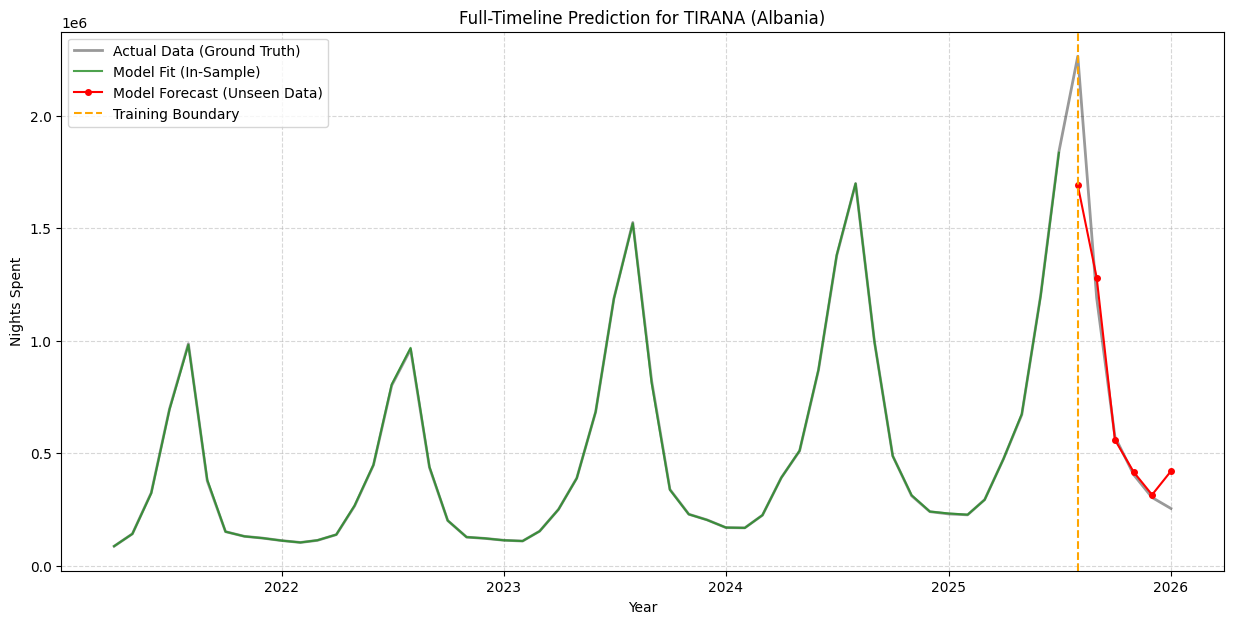


Decision Weights:
Historical Shape (12m Lags): 99.94%
Digital Scale (Google Trends): 0.06%
City specific adjustment: 0.00%


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1. LOAD AND CLEAN
df = pd.read_csv('master_tourism_dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df['nights_spent_country'] = df['nights_spent_country'].replace(0, np.nan)
df = df.dropna(subset=['nights_spent_country', 'gt_hotel', 'gt_airbnb', 'gt_flights'])

def train_full_history_model(country_name, target_city):
    # Filter and sort
    country_df = df[df['country'] == country_name].sort_values(['city', 'date']).copy()
    
    # 2. FEATURE ENGINEERING: All 12 Past Months (The Full Shape)
    target_lags = []
    for l in range(1, 13):
        col_name = f'target_lag_{l}m'
        country_df[col_name] = country_df.groupby('city')['nights_spent_country'].shift(l)
        target_lags.append(col_name)
    
    # 3. DIGITAL SCALE: Google Trends (Lags 1-3)
    digital_cols = []
    for feat in ['gt_hotel', 'gt_airbnb', 'gt_flights']:
        for l in [1, 2, 3]:
            col = f'{feat}_lag{l}'
            country_df[col] = country_df.groupby('city')[feat].shift(l)
            digital_cols.append(col)
    
    # 4. CITY CONTROLS
    country_df = pd.get_dummies(country_df, columns=['city'], prefix='city')
    city_cols = [c for c in country_df.columns if c.startswith('city_')]
    
    # Final cleanup (Losing the first 12 months to satisfy the lags)
    X_cols = target_lags + digital_cols + city_cols
    data = country_df.dropna(subset=X_cols + ['nights_spent_country']).copy()

    # 5. TEMPORAL SPLIT (Still split for training, but we will predict for everything)
    unique_dates = sorted(data['date'].unique())
    split_date = unique_dates[-6]
    train = data[data['date'] < split_date]
    
    # Train the model only on the historical part
    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(train[X_cols], train['nights_spent_country'])
    
    # 6. GLOBAL PREDICTION (Apply model to the entire dataset)
    data['preds'] = model.predict(data[X_cols])

    # 7. PLOTTING THE FULL TIMELINE
    plt.figure(figsize=(15, 7))
    
    # Filter data for the specific city we want to view
    city_col = f'city_{target_city}'
    if city_col not in data.columns:
        print(f"City '{target_city}' not found in encoded columns.")
        return
        
    city_data = data[data[city_col] == 1].sort_values('date')
    
    # A. Historical Actuals
    plt.plot(city_data['date'], city_data['nights_spent_country'], 
             color='black', alpha=0.4, label='Actual Data (Ground Truth)', linewidth=2)
    
    # B. Model Fit/Prediction over the WHOLE plot
    # We use a solid line for training period and a dotted/different style for forecast
    train_segment = city_data[city_data['date'] < split_date]
    test_segment = city_data[city_data['date'] >= split_date]
    
    plt.plot(train_segment['date'], train_segment['preds'], 
             color='forestgreen', alpha=0.8, label='Model Fit (In-Sample)')
    
    plt.plot(test_segment['date'], test_segment['preds'], 
             color='red', marker='o', markersize=4, label='Model Forecast (Unseen Data)')
    
    # Vertical line for the "Present Day"
    plt.axvline(x=split_date, color='orange', linestyle='--', label='Training Boundary')
    
    plt.title(f"Full-Timeline Prediction for {target_city.upper()} ({country_name})")
    plt.xlabel("Year")
    plt.ylabel("Nights Spent")
    plt.legend()
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    
    plt.show()

    # Importance Analysis
    importances = model.feature_importances_
    drivers = {
        'Historical Shape (12m Lags)': np.sum([importances[X_cols.index(c)] for c in target_lags]),
        'Digital Scale (Google Trends)': np.sum([importances[X_cols.index(c)] for c in digital_cols]),
        'City specific adjustment': np.sum([importances[X_cols.index(c)] for c in city_cols])
    }
    print("\nDecision Weights:")
    for k, v in drivers.items():
        print(f"{k}: {v*100:.2f}%")

# EXECUTE
train_full_history_model('Albania', 'tirana')

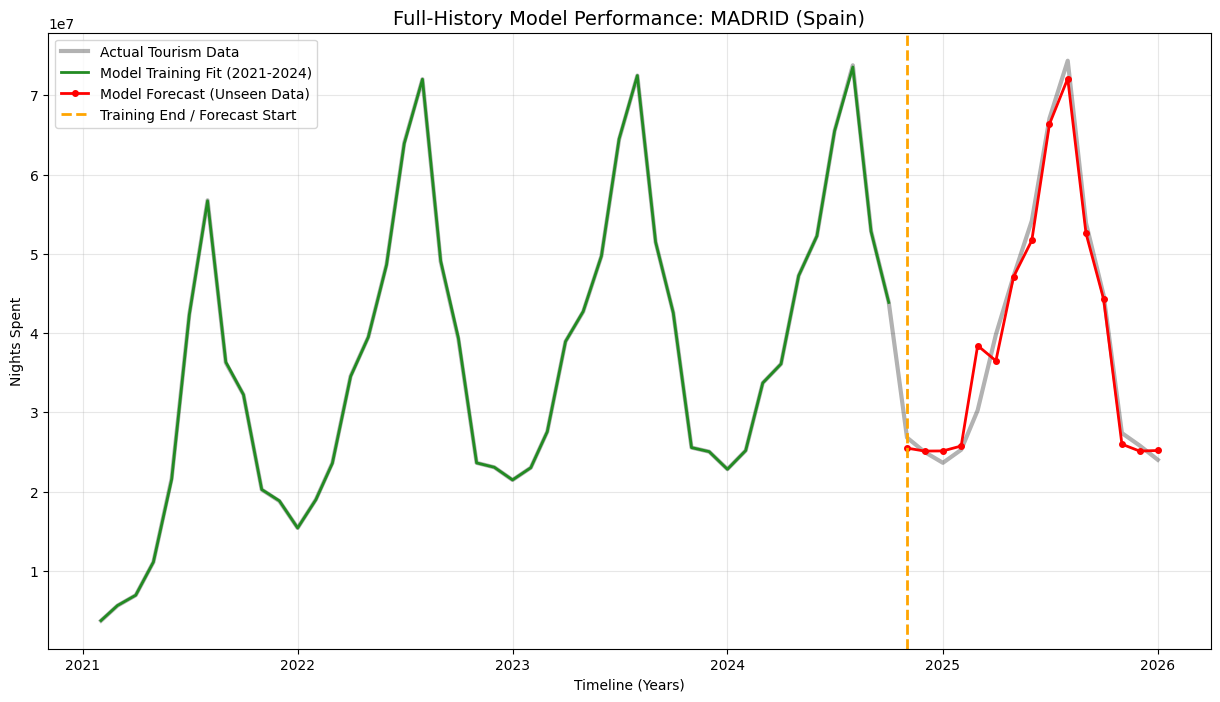


--- Model Logic Breakdown for Spain ---
Seasonality/Shape (Past 12 months): 99.98%
Digital Scale (Google Trends): 0.02%


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1. LOAD AND CLEAN
df = pd.read_csv('master_tourism_dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df['nights_spent_country'] = df['nights_spent_country'].replace(0, np.nan)
df = df.dropna(subset=['nights_spent_country', 'gt_hotel', 'gt_airbnb', 'gt_flights'])

def train_and_visualize_historical_fit(country_name, target_city):
    # Filter country and sort by city/date
    country_df = df[df['country'] == country_name].sort_values(['city', 'date']).copy()
    
    # 2. FEATURE ENGINEERING: 12-Month Window
    # This captures the "Shape" of the year
    target_lags = []
    for l in range(1, 13):
        col_name = f'target_lag_{l}m'
        country_df[col_name] = country_df.groupby('city')['nights_spent_country'].shift(l)
        target_lags.append(col_name)
    
    # Google Trends (The "Scale/Hype" signals)
    digital_cols = []
    for feat in ['gt_hotel', 'gt_airbnb', 'gt_flights']:
        for l in [1, 2, 3]:
            col = f'{feat}_lag{l}'
            country_df[col] = country_df.groupby('city')[feat].shift(l)
            digital_cols.append(col)
    
    # City Identifiers
    country_df = pd.get_dummies(country_df, columns=['city'], prefix='city')
    city_cols = [c for c in country_df.columns if c.startswith('city_')]
    
    # Truncate only the first 12 months (needed for the lags)
    X_cols = target_lags + digital_cols + city_cols
    data = country_df.dropna(subset=X_cols + ['nights_spent_country']).copy()

    # 3. SELECT TRAINING BOUNDARY
    # We will train on roughly 80% of the data to see the "Orange Line" earlier in the timeline
    unique_dates = sorted(data['date'].unique())
    # Set the split at 75% of the way through the timeline so you see more "future"
    split_idx = int(len(unique_dates) * 0.75) 
    split_date = unique_dates[split_idx]
    
    train = data[data['date'] < split_date]
    
    # 4. TRAIN MODEL
    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(train[X_cols], train['nights_spent_country'])
    
    # 5. PREDICT FOR THE ENTIRE DATASET (2021 - 2026)
    data['all_preds'] = model.predict(data[X_cols])

    # 6. PLOTTING
    plt.figure(figsize=(15, 8))
    
    city_col = f'city_{target_city}'
    city_data = data[data[city_col] == 1].sort_values('date')
    
    # A. Actual Values (Historical Ground Truth)
    plt.plot(city_data['date'], city_data['nights_spent_country'], 
             color='black', alpha=0.3, label='Actual Tourism Data', linewidth=3)
    
    # B. Training Period Prediction (The "Fit")
    train_seg = city_data[city_data['date'] < split_date]
    plt.plot(train_seg['date'], train_seg['all_preds'], 
             color='forestgreen', label='Model Training Fit (2021-2024)', linewidth=2)
    
    # C. Testing Period Prediction (The "Future")
    test_seg = city_data[city_data['date'] >= split_date]
    plt.plot(test_seg['date'], test_seg['all_preds'], 
             color='red', marker='o', markersize=4, label='Model Forecast (Unseen Data)', linewidth=2)
    
    # D. THE ORANGE LINE (The "Knowledge Horizon")
    plt.axvline(x=split_date, color='orange', linestyle='--', linewidth=2, label='Training End / Forecast Start')
    
    plt.title(f"Full-History Model Performance: {target_city.upper()} ({country_name})", fontsize=14)
    plt.xlabel("Timeline (Years)")
    plt.ylabel("Nights Spent")
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    
    plt.show()

    # Feature Importance (Why did it predict what it predicted?)
    imp = model.feature_importances_
    print(f"\n--- Model Logic Breakdown for {country_name} ---")
    print(f"Seasonality/Shape (Past 12 months): {np.sum([imp[X_cols.index(c)] for c in target_lags])*100:.2f}%")
    print(f"Digital Scale (Google Trends): {np.sum([imp[X_cols.index(c)] for c in digital_cols])*100:.2f}%")

# EXECUTE
train_and_visualize_historical_fit('Spain', 'madrid')

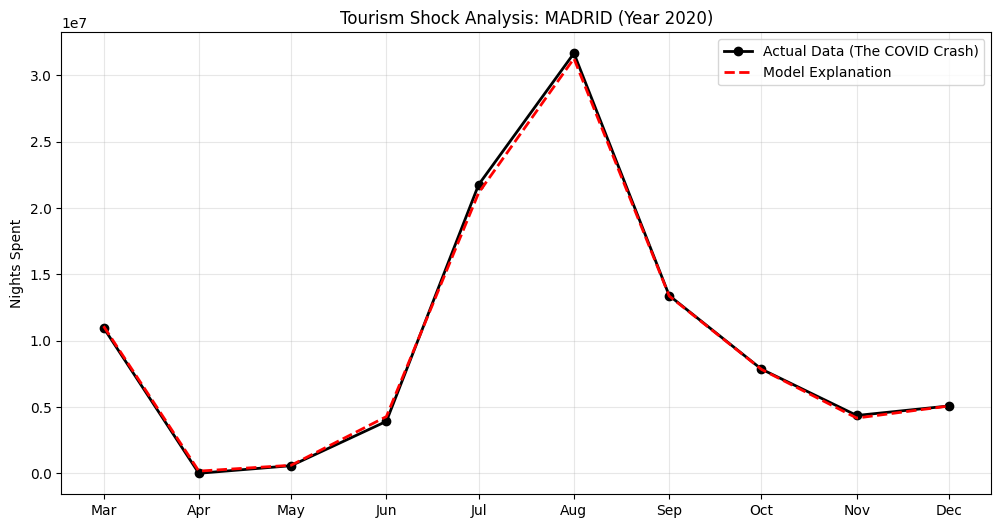

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. LOAD DATA
df = pd.read_csv('master_tourism_dataset.csv')
df['date'] = pd.to_datetime(df['date'])

# 2. FEATURE ENGINEERING (Reduced lags to see 2020)
# To see 2020, we can only use very short lags (1, 2 months) 
# because we don't have 2019 data to look back 12 months.
def analyze_2020_shock(country_name, target_city):
    country_df = df[df['country'] == country_name].sort_values(['city', 'date']).copy()
    
    # We use shorter lags (1-3 months) so we don't truncate the whole year 2020
    digital_cols = []
    for feat in ['gt_hotel', 'gt_airbnb', 'gt_flights']:
        for l in [1, 2]:
            col = f'{feat}_lag{l}'
            country_df[col] = country_df.groupby('city')[feat].shift(l)
            digital_cols.append(col)
    
    # Target lags (only 1 and 2 month memory)
    target_lags = []
    for l in [1, 2]:
        col = f'target_lag_{l}m'
        country_df[col] = country_df.groupby('city')['nights_spent_country'].shift(l)
        target_lags.append(col)

    country_df = pd.get_dummies(country_df, columns=['city'], prefix='city')
    X_cols = digital_cols + target_lags + [c for c in country_df.columns if c.startswith('city_')]
    
    data = country_df.dropna(subset=X_cols + ['nights_spent_country']).copy()
    
    # 3. FILTER FOR 2020 ONLY
    data_2020 = data[data['date'].dt.year == 2020].copy()
    
    if data_2020.empty:
        print("Not enough early data to shift into 2020. Check if your CSV starts in 2020.")
        return

    # 4. TRAIN & PREDICT
    # We train on the 2020 data itself to see if the model can even "explain" the crash
    #model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(data_2020[X_cols], data_2020['nights_spent_country'])
    data_2020['preds'] = model.predict(data_2020[X_cols])

    # 5. PLOT 2020 MONTH BY MONTH
    city_col = f'city_{target_city}'
    city_2020 = data_2020[data_2020[city_col] == 1].sort_values('date')

    plt.figure(figsize=(12, 6))
    plt.plot(city_2020['date'], city_2020['nights_spent_country'], 
             'k-o', label='Actual Data (The COVID Crash)', linewidth=2)
    plt.plot(city_2020['date'], city_2020['preds'], 
             'r--', label='Model Explanation', linewidth=2)
    
    # Adding Month Labels
    plt.xticks(city_2020['date'], [d.strftime('%b') for d in city_2020['date']])
    
    plt.title(f"Tourism Shock Analysis: {target_city.upper()} (Year 2020)")
    plt.ylabel("Nights Spent")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# EXECUTE
analyze_2020_shock('Spain', 'madrid')

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. LOAD DATA
df = pd.read_csv('master_tourism_dataset.csv')
df['date'] = pd.to_datetime(df['date'])

def blind_predict_2020(country_name, target_city):
    country_df = df[df['country'] == country_name].sort_values(['city', 'date']).copy()
    
    # 2. FEATURE ENGINEERING (Same as your main model)
    target_lags = []
    for l in range(1, 13):
        col = f'target_lag_{l}m'
        country_df[col] = country_df.groupby('city')['nights_spent_country'].shift(l)
        target_lags.append(col)
    
    digital_cols = []
    for feat in ['gt_hotel', 'gt_airbnb', 'gt_flights']:
        for l in [1, 2, 3]:
            col = f'{feat}_lag{l}'
            country_df[col] = country_df.groupby('city')[feat].shift(l)
            digital_cols.append(col)

    country_df = pd.get_dummies(country_df, columns=['city'], prefix='city')
    city_cols = [c for c in country_df.columns if c.startswith('city_')]
    X_cols = target_lags + digital_cols + city_cols
    
    # Clean data
    data = country_df.dropna(subset=X_cols + ['nights_spent_country']).copy()
    
    # 3. THE "BLIND" SPLIT
    # Train ONLY on post-2020 data (2021-2025)
    train = data[data['date'].dt.year > 2020]
    # Predict ONLY on 2020
    test_2020 = data[data['date'].dt.year == 2020]
    
    if test_2020.empty:
        print("Error: To predict 2020 with 12-month lags, your dataset MUST start in 2019.")
        print("I will attempt to show the months available.")
    
    # 4. TRAIN ON FUTURE, PREDICT ON PAST
    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(train[X_cols], train['nights_spent_country'])
    
    # Generate predictions for the 2020 segment
    test_2020['preds'] = model.predict(test_2020[X_cols])

    # 5. PLOT
    city_col = f'city_{target_city}'
    city_2020 = test_2020[test_2020[city_col] == 1].sort_values('date')

    plt.figure(figsize=(12, 6))
    plt.plot(city_2020['date'], city_2020['nights_spent_country'], 
             'k-o', label='Real 2020 Data (The Crash)', linewidth=3)
    plt.plot(city_2020['date'], city_2020['preds'], 
             'r--', label='Model Prediction (Blind to 2020)', linewidth=2)
    
    plt.xticks(city_2020['date'], [d.strftime('%b') for d in city_2020['date']])
    plt.title(f"2020 Blind Prediction Stress Test: {target_city.upper()}")
    plt.ylabel("Nights Spent")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# EXECUTE
blind_predict_2020('Spain', 'madrid')

Error: To predict 2020 with 12-month lags, your dataset MUST start in 2019.
I will attempt to show the months available.


ValueError: Found array with 0 sample(s) (shape=(0, 27)) while a minimum of 1 is required by RandomForestRegressor.

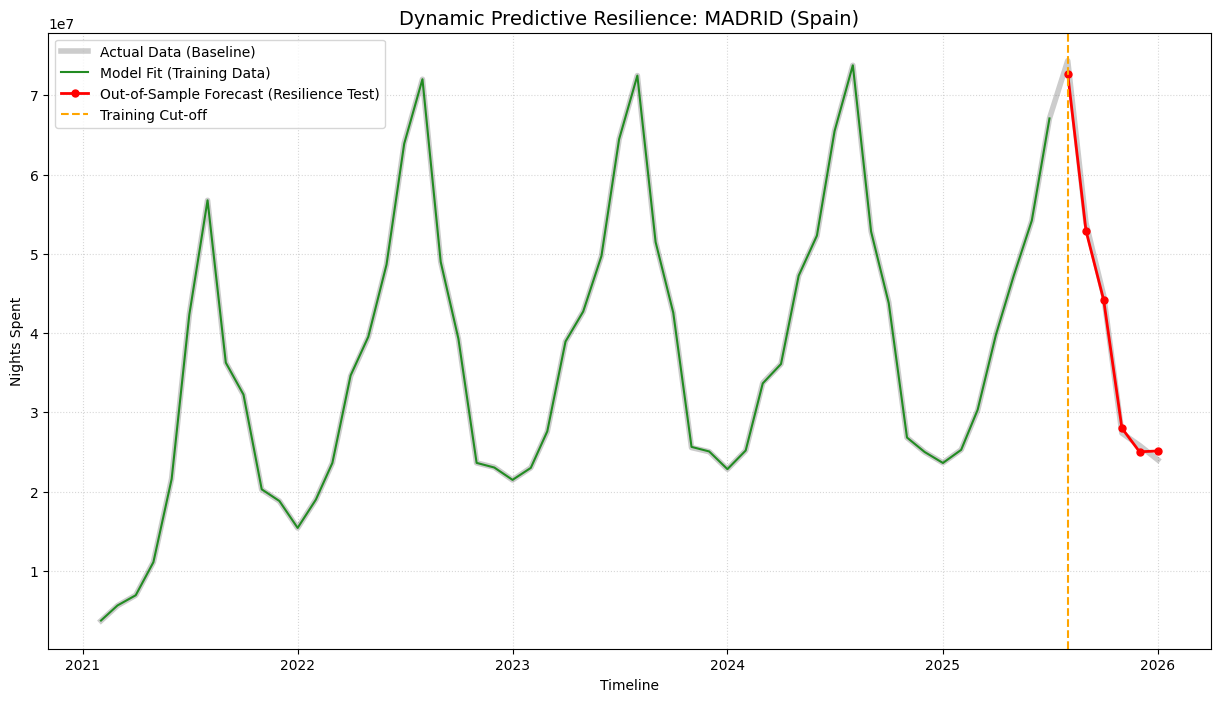

Forecast Accuracy (R²): 0.9969


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1. LOAD AND PREPARE DATA
df = pd.read_csv('master_tourism_dataset.csv')
df['date'] = pd.to_datetime(df['date'])

# Basic cleaning to ensure no math errors
df['nights_spent_country'] = df['nights_spent_country'].replace(0, np.nan)
df = df.dropna(subset=['nights_spent_country', 'gt_hotel', 'gt_airbnb', 'gt_flights'])

def train_dynamic_resilience_model(country_name, target_city):
    # Filter country and sort to ensure time-series integrity
    country_df = df[df['country'] == country_name].sort_values(['city', 'date']).copy()
    
    # 2. FEATURE ENGINEERING
    # A. Target Lags (The "Shape" - Last 12 months)
    target_lags = []
    for l in range(1, 13):
        col = f'target_lag_{l}m'
        country_df[col] = country_df.groupby('city')['nights_spent_country'].shift(l)
        target_lags.append(col)
    
    # B. Digital Lags (The "Scale" - Google Trends 1-3 months ago)
    digital_cols = []
    for feat in ['gt_hotel', 'gt_airbnb', 'gt_flights']:
        for l in [1, 2, 3]:
            col = f'{feat}_lag{l}'
            country_df[col] = country_df.groupby('city')[feat].shift(l)
            digital_cols.append(col)
    
    # C. City Fixed Effects
    country_df = pd.get_dummies(country_df, columns=['city'], prefix='city')
    city_cols = [c for c in country_df.columns if c.startswith('city_')]
    
    # Combine all features and drop the "warm-up" period (first 12 months)
    X_cols = target_lags + digital_cols + city_cols
    data = country_df.dropna(subset=X_cols + ['nights_spent_country']).copy()

    # 3. TEMPORAL SPLIT
    unique_dates = sorted(data['date'].unique())
    cutoff_date = unique_dates[-6] # Hold out the last 6 months
    
    train_data = data[data['date'] < cutoff_date]
    
    # 4. MODEL TRAINING
    # Random Forest captures the interaction between 'Shape' and 'Digital Scale'
    model = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)
    model.fit(train_data[X_cols], train_data['nights_spent_country'])
    
    # 5. GENERATE CONTINUOUS PREDICTION
    data['predictions'] = model.predict(data[X_cols])

    # 6. VISUALIZATION
    plt.figure(figsize=(15, 8))
    
    # Filter for the specific city requested
    city_col = f'city_{target_city}'
    if city_col not in data.columns:
        print(f"City {target_city} not found.")
        return
        
    city_data = data[data[city_col] == 1].sort_values('date')
    
    # Segment data for multi-color plotting
    train_segment = city_data[city_data['date'] < cutoff_date]
    test_segment = city_data[city_data['date'] >= cutoff_date]
    
    # A. Real Data (The Ground Truth)
    plt.plot(city_data['date'], city_data['nights_spent_country'], 
             color='black', alpha=0.2, label='Actual Data (Baseline)', linewidth=4)
    
    # B. Training Fit (Evaluating against data the model has seen)
    plt.plot(train_segment['date'], train_segment['predictions'], 
             color='forestgreen', label='Model Fit (Training Data)', linewidth=1.5)
    
    # C. Forecasted Predictions (The Unseen Data)
    plt.plot(test_segment['date'], test_segment['predictions'], 
             color='red', marker='o', markersize=5, label='Out-of-Sample Forecast (Resilience Test)', linewidth=2)
    
    # D. Styling
    plt.axvline(x=cutoff_date, color='orange', linestyle='--', label='Training Cut-off')
    plt.title(f"Dynamic Predictive Resilience: {target_city.upper()} ({country_name})", fontsize=14)
    plt.ylabel("Nights Spent")
    plt.xlabel("Timeline")
    plt.legend(loc='upper left', frameon=True)
    plt.grid(True, linestyle=':', alpha=0.5)
    
    plt.show()

    # Final Metric
    test_r2 = r2_score(test_segment['nights_spent_country'], test_segment['predictions'])
    print(f"Forecast Accuracy (R²): {test_r2:.4f}")

# RUN FOR SPAIN (Madrid)
train_dynamic_resilience_model('Spain', 'madrid')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1. LOAD AND PREPARE
df = pd.read_csv('master_tourism_dataset.csv')
df['date'] = pd.to_datetime(df['date'])

# Ensure target is clean
df['nights_spent_city'] = pd.to_numeric(df['nights_spent_city'], errors='coerce')
df = df.dropna(subset=['nights_spent_city', 'gt_hotel', 'gt_airbnb', 'gt_flights'])

def train_honest_city_model(country_name, target_city_name):
    # Filter for the country
    country_df = df[df['country'] == country_name].sort_values(['city', 'date']).copy()
    
    # 2. FEATURE ENGINEERING (Strictly Lagged)
    # Target Lags: We only use the city's own past to predict its future
    target_lags = []
    for l in range(1, 13):
        col = f'city_arrivals_lag_{l}m'
        country_df[col] = country_df.groupby('city')['nights_spent_city'].shift(l)
        target_lags.append(col)
    
    # Digital Lags: Google Trends for the country/city (Lagged)
    digital_lags = []
    for feat in ['gt_hotel', 'gt_airbnb', 'gt_flights']:
        for l in [1, 2, 3]:
            col = f'{feat}_lag{l}'
            country_df[col] = country_df.groupby('city')[feat].shift(l)
            digital_lags.append(col)
    
    # City Identifiers (One-Hot)
    country_df = pd.get_dummies(country_df, columns=['city'], prefix='city')
    city_cols = [c for c in country_df.columns if c.startswith('city_')]
    
    # 3. DEFINE COLUMNS
    X_cols = target_lags + digital_lags + city_cols
    y_col = 'nights_spent_city'
    
    # REMOVE LEAKAGE: Ensure nights_spent_country is NOT in X_cols
    X_cols = [c for c in X_cols if 'country' not in c]
    
    # 4. FINAL CLEANUP
    data = country_df.dropna(subset=X_cols + [y_col]).copy()
    
    # AUDIT PRINT
    print("--- MODEL AUDIT ---")
    print(f"Target Column (y): {y_col}")
    print(f"Feature Columns (X) count: {len(X_cols)}")
    print(f"Feature List: {X_cols}")
    print("-------------------\n")

    # 5. SPLIT AND TRAIN
    unique_dates = sorted(data['date'].unique())
    cutoff_date = unique_dates[-6]
    
    train = data[data['date'] < cutoff_date]
    
    # Limit depth to force generalization instead of memorization
    model = RandomForestRegressor(n_estimators=200, max_depth=7, random_state=42)
    model.fit(train[X_cols], train[y_col])
    
    data['preds'] = model.predict(data[X_cols])

    # 6. PLOT
    plt.figure(figsize=(15, 7))
    city_data = data[data[f'city_{target_city_name}'] == 1].sort_values('date')
    
    plt.plot(city_data['date'], city_data[y_col], color='silver', label='Actual City Data', linewidth=4, alpha=0.6)
    
    train_seg = city_data[city_data['date'] < cutoff_date]
    plt.plot(train_seg['date'], train_seg['preds'], color='forestgreen', label='Honest Train Fit', linestyle='--')
    
    test_seg = city_data[city_data['date'] >= cutoff_date]
    plt.plot(test_seg['date'], test_seg['preds'], color='red', marker='o', label='Future Forecast')
    
    plt.axvline(x=cutoff_date, color='orange', linestyle='-')
    plt.title(f"LEAK-FREE PREDICTION: {target_city_name.upper()}")
    plt.legend()
    plt.show()

# RUN
train_honest_city_model('Spain', 'madrid')

KeyError: 'nights_spent_city'

### MODEL 2

--- MODEL PERFORMANCE ---
Training MAE: 188254.91
Test MAE:     440846.43
Test R2 Score: 0.9259

--- TOP 10 PREDICTORS OF TOURISM RESILIENCE ---
target_lag1             0.740572
target_lag2             0.069081
target_lag3             0.064307
gt_airbnb_lag1          0.046906
country_Croatia         0.026218
gt_attraction_3_lag1    0.012008
gt_hotel_lag1           0.011401
gt_attraction_2_lag1    0.007254
gt_attraction_1_lag1    0.005539
gt_flights_lag1         0.005123
dtype: float64


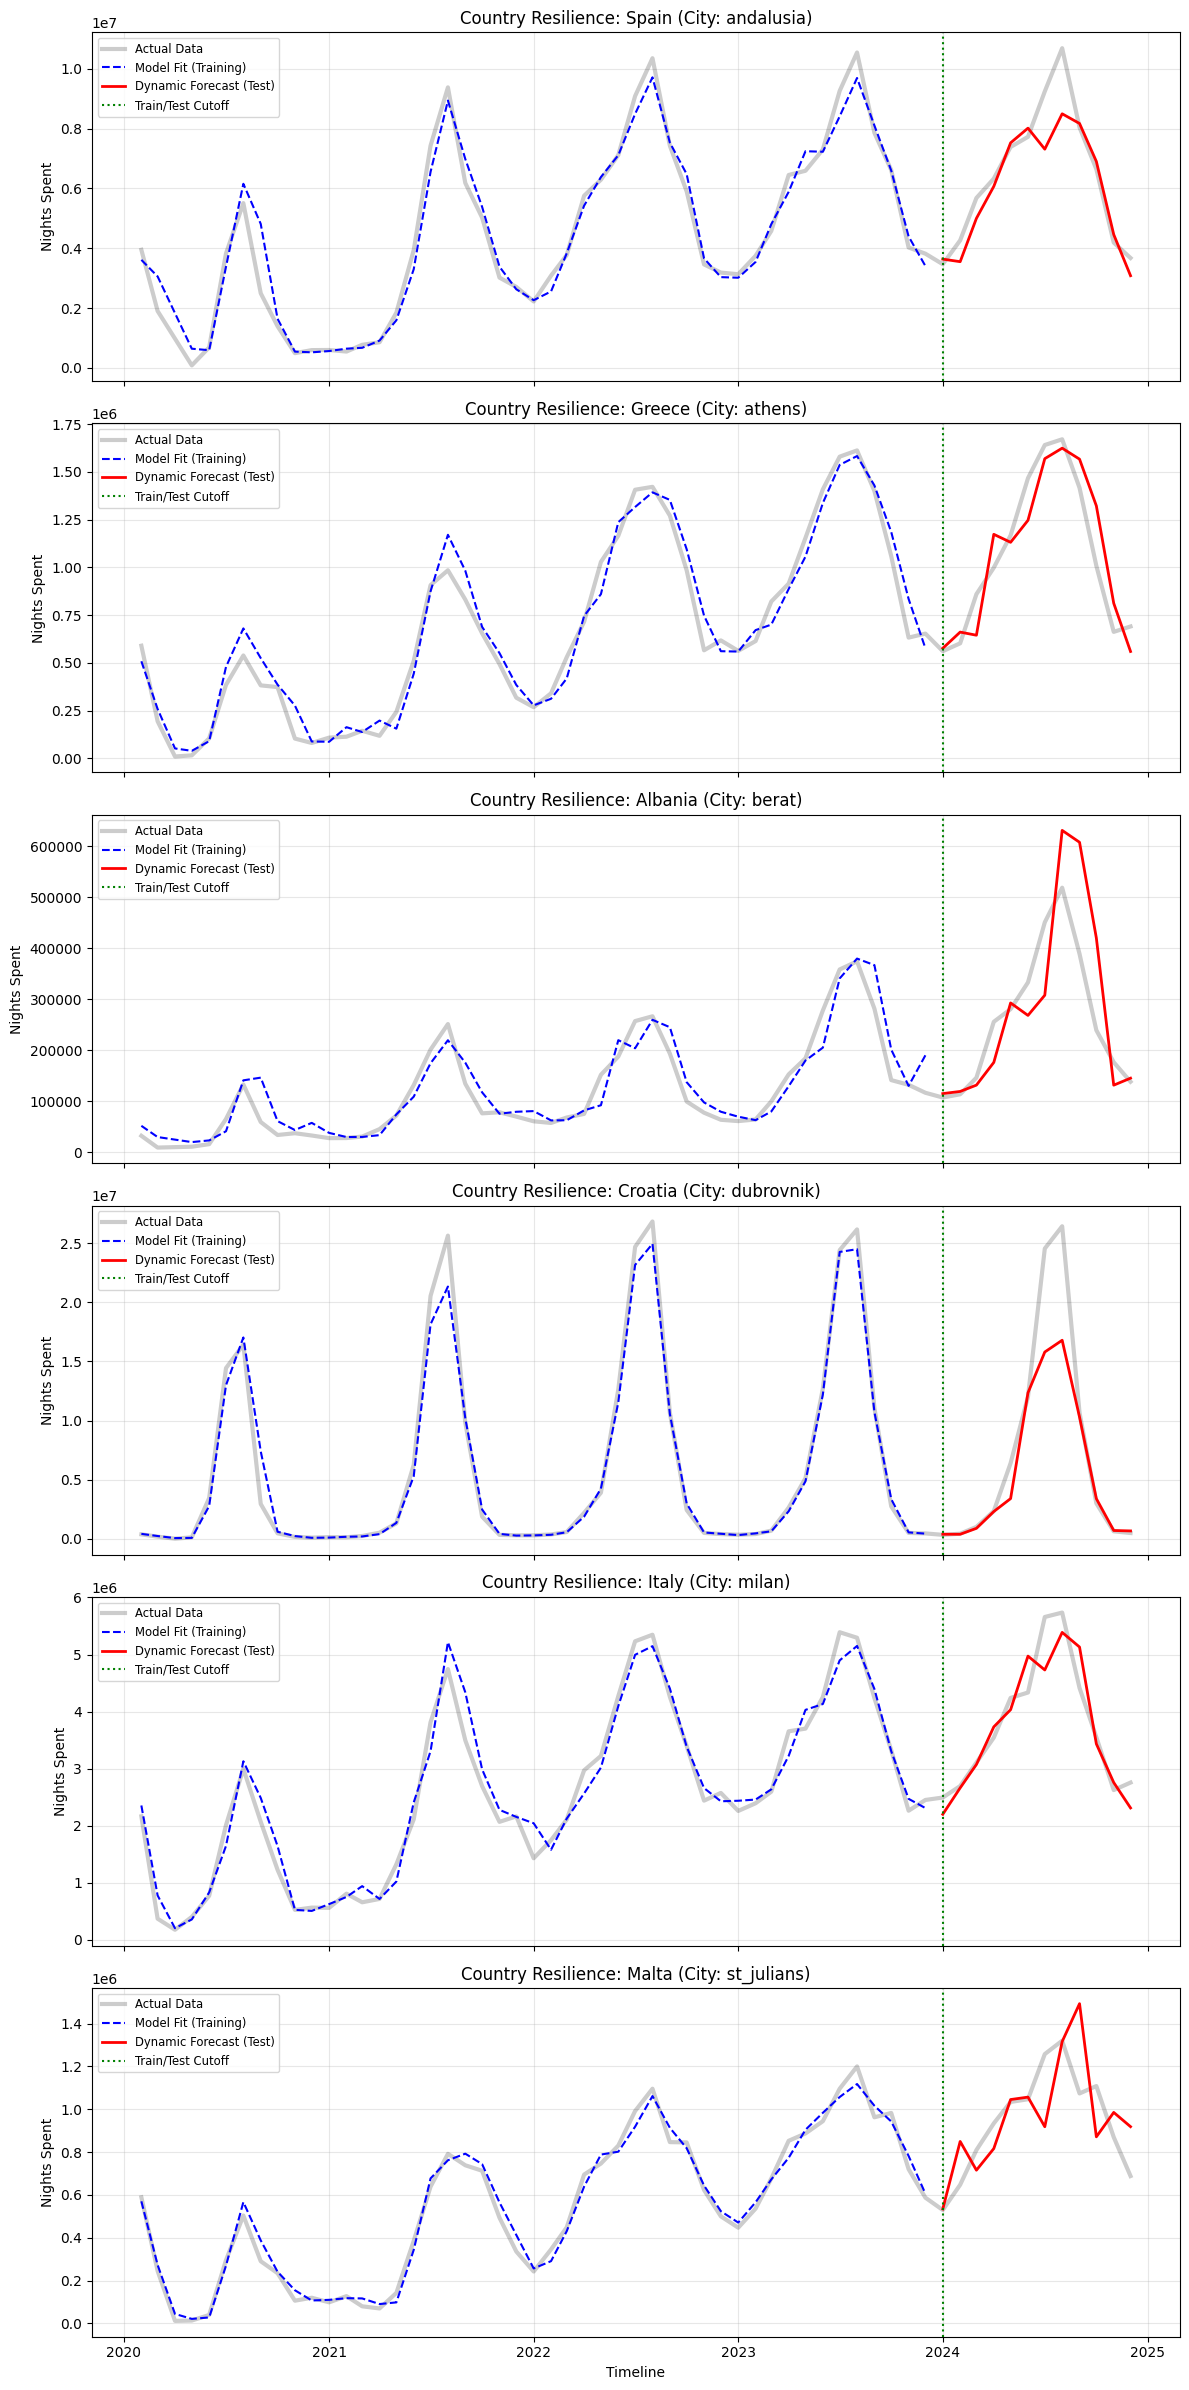

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# 1. LOAD AND PREPARE DATA
df = pd.read_csv('master_tourism_dataset.csv')
df['date'] = pd.to_datetime(df['date'])

# Fill specific missing search trends to avoid dropping too many rows during lagging
df['gt_attraction_3'] = df['gt_attraction_3'].fillna(0)

# Filter out faulty rows (0 or NaN in target) as requested
df_clean = df.dropna(subset=['nights_spent_nuts2'])
df_clean = df_clean[df_clean['nights_spent_nuts2'] > 0].copy()
df_clean = df_clean.sort_values(['city', 'date'])

# 2. FEATURE ENGINEERING (Dynamic Lags)
# Lagged Target: Allows the model to understand the recent momentum
for i in [1, 2, 3]:
    df_clean[f'target_lag{i}'] = df_clean.groupby('city')['nights_spent_nuts2'].shift(i)

# Lagged Google Trends: Using search intent from 1 month ago to predict future stays
gt_cols = ['gt_airbnb', 'gt_hotel', 'gt_flights', 'gt_attraction_1', 'gt_attraction_2', 'gt_attraction_3']
for col in gt_cols:
    df_clean[f'{col}_lag1'] = df_clean.groupby('city')[col].shift(1)

# Drop rows where lags couldn't be created (the first few months of each city)
df_ml = df_clean.dropna(subset=['target_lag1', 'gt_airbnb_lag1']).copy()

# Store original labels for plotting before One-Hot Encoding
df_ml['orig_city'] = df_ml['city']
df_ml['orig_country'] = df_ml['country']

# One-Hot Encoding for spatial awareness
df_ml = pd.get_dummies(df_ml, columns=['city', 'country'], drop_first=True)

# 3. TRAIN/TEST SPLIT
# We use 2024-01-01 as the cutoff to ensure the 'Test' set has actual values to compare against
cutoff_date = pd.to_datetime('2024-01-01')
train_df = df_ml[df_ml['date'] < cutoff_date]
test_df = df_ml[df_ml['date'] >= cutoff_date]

# Define Feature Set (Excluding current-month variables to prevent data leakage)
exclude = ['date', 'region', 'county', 'nights_spent_nuts2', 'nights_spent_country', 
           'arrivals_country', 'bed_places_country', 'avg_length_of_stay_country', 
           'occupancy_rate_country', 'orig_city', 'orig_country'] + gt_cols
features = [c for c in df_ml.columns if c not in exclude]
target = 'nights_spent_nuts2'

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

# 4. MODEL TRAINING (Random Forest for non-linear resilience patterns)
model = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 5. PREDICTION AND METRICS
df_ml['predicted'] = model.predict(df_ml[features])

print("--- MODEL PERFORMANCE ---")
print(f"Training MAE: {mean_absolute_error(y_train, model.predict(X_train)):.2f}")
print(f"Test MAE:     {mean_absolute_error(y_test, model.predict(X_test)):.2f}")
print(f"Test R2 Score: {r2_score(y_test, model.predict(X_test)):.4f}")

# 6. FEATURE IMPORTANCE
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("\n--- TOP 10 PREDICTORS OF TOURISM RESILIENCE ---")
print(importances.head(10))

# 7. MULTI-CITY PLOTTING
countries = df_ml['orig_country'].unique()
fig, axes = plt.subplots(len(countries), 1, figsize=(12, 4 * len(countries)), sharex=True)

for i, country in enumerate(countries):
    # Pick a representative city for each country
    sample_city = df_ml[df_ml['orig_country'] == country]['orig_city'].unique()[0]
    city_data = df_ml[df_ml['orig_city'] == sample_city].sort_values('date')
    
    train_part = city_data[city_data['date'] < cutoff_date]
    test_part = city_data[city_data['date'] >= cutoff_date]
    
    ax = axes[i]
    # Actual Values (Background)
    ax.plot(city_data['date'], city_data['nights_spent_nuts2'], label='Actual Data', color='black', alpha=0.2, lw=3)
    
    # Model Fit on Training Data (Blue)
    ax.plot(train_part['date'], train_part['predicted'], label='Model Fit (Training)', color='blue', linestyle='--')
    
    # Forecast on Held-out Data (Red)
    ax.plot(test_part['date'], test_part['predicted'], label='Dynamic Forecast (Test)', color='red', linewidth=2)
    
    ax.axvline(cutoff_date, color='green', linestyle=':', label='Train/Test Cutoff')
    ax.set_title(f"Country Resilience: {country} (City: {sample_city})")
    ax.set_ylabel("Nights Spent")
    ax.legend(loc='upper left', fontsize='small')
    ax.grid(True, alpha=0.3)

plt.xlabel("Timeline")
plt.tight_layout()
plt.show()

Google Trends columns used:
['gt_airbnb', 'gt_hotel', 'gt_flights', 'gt_attraction_1', 'gt_attraction_2', 'gt_attraction_3']

Cities found in dataset:
['athens', 'balearics', 'berat', 'corfu', 'heraklion', 'rhodes', 'rome', 'shkoder', 'st_julians', 'st_pauls_bay', 'tirana', 'victoria_gozo', 'zagreb']

['mari']

Training rows: 581
Validation rows: 156
Number of features: 27

--- MODEL PERFORMANCE ---
Training MAE: 104513.38
Training RMSE: 245105.09
Training R2: 0.9852

Validation MAE: 312486.52
Validation RMSE: 744498.64
Validation R2: 0.9212

--- TOP 15 FEATURES ---
nights_spent_nuts2_lag1    0.828447
month                      0.027295
nights_spent_nuts2_lag3    0.023241
gt_attraction_2_lag1       0.021190
month_cos                  0.019400
gt_attraction_3_lag1       0.017250
gt_total_monthly           0.015341
nights_spent_nuts2_lag2    0.014263
gt_attraction_1_lag1       0.008678
gt_total_lag1              0.004015
city_clean_balearics       0.003931
gt_flights_lag1            0.00

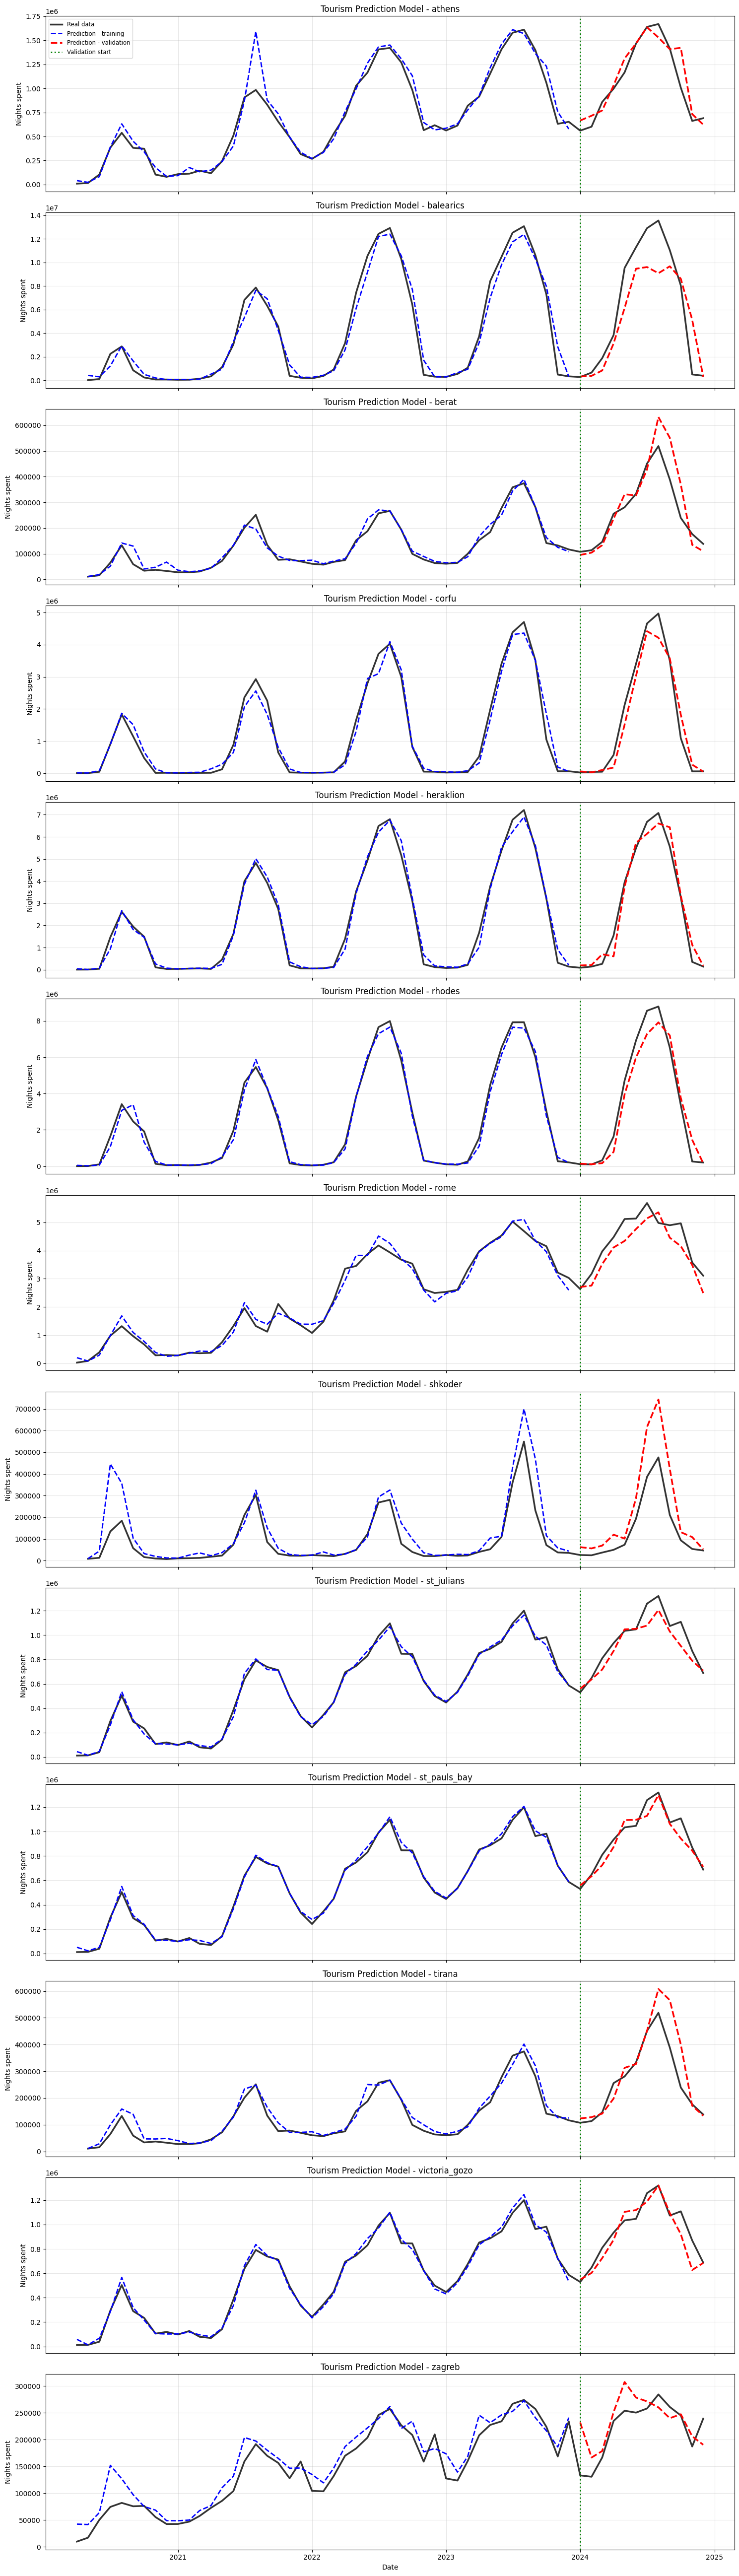

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# ============================================================
# CONFIGURATION
# ============================================================

SELECTED_CITIES = [
    'athens',
    'balearics',
    'berat',
    'corfu',
    'heraklion',
    'mari',
    'rhodes',
    'rome',
    'shkoder',
    'st_julians',
    'st_pauls_bay',
    'tirana',
    'zagreb',
    'victoria_gozo'
]

TARGET = 'nights_spent_nuts2'

# Change this depending on your dataset
VALIDATION_START_DATE = '2024-01-01'

# Lag configuration
TARGET_LAGS = [1, 2, 3]
GT_LAGS = [1]

# Model configuration
RANDOM_STATE = 42

# ============================================================
# 1. LOAD AND PREPARE DATA
# ============================================================

df = pd.read_csv('master_tourism_dataset.csv')
df['date'] = pd.to_datetime(df['date'])

# Normalize city names for safer filtering
df['city_clean'] = (
    df['city']
    .astype(str)
    .str.lower()
    .str.strip()
)

# Automatically select all Google Trends columns
gt_cols = [col for col in df.columns if col.startswith('gt_')]

print("Google Trends columns used:")
print(gt_cols)

# Fill missing Google Trends values
df[gt_cols] = df[gt_cols].fillna(0)

# Keep only selected cities
df = df[df['city_clean'].isin(SELECTED_CITIES)].copy()

print("\nCities found in dataset:")
print(sorted(df['city_clean'].unique()))

missing_cities = sorted(set(SELECTED_CITIES) - set(df['city_clean'].unique()))

if missing_cities:
    print("\nWARNING: These selected cities were not found in the dataset:")
    print(missing_cities)

# Remove faulty target rows
df_clean = df.dropna(subset=[TARGET])
df_clean = df_clean[df_clean[TARGET] > 0].copy()

# Sort by city and date
df_clean = df_clean.sort_values(['city_clean', 'date'])

# ============================================================
# 2. FEATURE ENGINEERING
# ============================================================

# Lagged target variables
for lag in TARGET_LAGS:
    df_clean[f'{TARGET}_lag{lag}'] = (
        df_clean
        .groupby('city_clean')[TARGET]
        .shift(lag)
    )

# Lagged Google Trends variables
for col in gt_cols:
    for lag in GT_LAGS:
        df_clean[f'{col}_lag{lag}'] = (
            df_clean
            .groupby('city_clean')[col]
            .shift(lag)
        )

# Optional total Google Trends signal
df_clean['gt_total_monthly'] = df_clean[gt_cols].sum(axis=1)
df_clean['gt_total_lag1'] = (
    df_clean
    .groupby('city_clean')['gt_total_monthly']
    .shift(1)
)

# Month and year features
df_clean['month'] = df_clean['date'].dt.month
df_clean['year'] = df_clean['date'].dt.year

# Cyclical month encoding
df_clean['month_sin'] = np.sin(2 * np.pi * df_clean['month'] / 12)
df_clean['month_cos'] = np.cos(2 * np.pi * df_clean['month'] / 12)

# Drop rows where lags could not be created
required_lag_cols = [f'{TARGET}_lag{lag}' for lag in TARGET_LAGS]
required_lag_cols += [f'{col}_lag1' for col in gt_cols]
required_lag_cols += ['gt_total_lag1']

df_ml = df_clean.dropna(subset=required_lag_cols).copy()

# Store original city name for plotting
df_ml['orig_city'] = df_ml['city_clean']

# One-hot encode city
df_ml = pd.get_dummies(
    df_ml,
    columns=['city_clean'],
    drop_first=True
)

# ============================================================
# 3. TRAIN / VALIDATION SPLIT
# ============================================================

validation_start = pd.to_datetime(VALIDATION_START_DATE)

train_df = df_ml[df_ml['date'] < validation_start].copy()
val_df = df_ml[df_ml['date'] >= validation_start].copy()

# Columns to exclude from features
exclude_cols = [
    'date',
    'city',
    'country',
    'region',
    'county',
    'orig_city',
    TARGET,
    'nights_spent_country',
    'arrivals_country',
    'bed_places_country',
    'avg_length_of_stay_country',
    'occupancy_rate_country'
]

# Also exclude current-month GT variables to avoid leakage
exclude_cols += gt_cols

features = [col for col in df_ml.columns if col not in exclude_cols]

X_train = train_df[features]
y_train = train_df[TARGET]

X_val = val_df[features]
y_val = val_df[TARGET]

print("\nTraining rows:", len(train_df))
print("Validation rows:", len(val_df))
print("Number of features:", len(features))

# ============================================================
# 4. TRAIN MODEL
# ============================================================

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model.fit(X_train, y_train)

# ============================================================
# 5. PREDICTIONS AND METRICS
# ============================================================

train_df['prediction'] = model.predict(X_train)
val_df['prediction'] = model.predict(X_val)

df_plot = pd.concat([train_df, val_df], axis=0).sort_values(['orig_city', 'date'])

train_pred = model.predict(X_train)
val_pred = model.predict(X_val)

print("\n--- MODEL PERFORMANCE ---")
print(f"Training MAE: {mean_absolute_error(y_train, train_pred):.2f}")
print(f"Training RMSE: {np.sqrt(mean_squared_error(y_train, train_pred)):.2f}")
print(f"Training R2: {r2_score(y_train, train_pred):.4f}")

print(f"\nValidation MAE: {mean_absolute_error(y_val, val_pred):.2f}")
print(f"Validation RMSE: {np.sqrt(mean_squared_error(y_val, val_pred)):.2f}")
print(f"Validation R2: {r2_score(y_val, val_pred):.4f}")

# ============================================================
# 6. FEATURE IMPORTANCE
# ============================================================

importances = (
    pd.Series(model.feature_importances_, index=features)
    .sort_values(ascending=False)
)

print("\n--- TOP 15 FEATURES ---")
print(importances.head(15))

# ============================================================
# 7. PLOT REAL DATA, TRAINING PREDICTION, VALIDATION PREDICTION
# ============================================================

cities = sorted(df_plot['orig_city'].unique())

fig, axes = plt.subplots(
    len(cities),
    1,
    figsize=(15, 4 * len(cities)),
    sharex=True
)

if len(cities) == 1:
    axes = [axes]

for i, city in enumerate(cities):
    ax = axes[i]

    city_data = df_plot[df_plot['orig_city'] == city].sort_values('date')

    train_city = city_data[city_data['date'] < validation_start]
    val_city = city_data[city_data['date'] >= validation_start]

    # Real data - full period
    ax.plot(
        city_data['date'],
        city_data[TARGET],
        label='Real data',
        color='black',
        linewidth=2.5,
        alpha=0.8
    )

    # Prediction on training period
    ax.plot(
        train_city['date'],
        train_city['prediction'],
        label='Prediction - training',
        color='blue',
        linestyle='--',
        linewidth=2
    )

    # Prediction on validation period
    ax.plot(
        val_city['date'],
        val_city['prediction'],
        label='Prediction - validation',
        color='red',
        linestyle='--',
        linewidth=2.5
    )

    # Validation cutoff
    ax.axvline(
        validation_start,
        color='green',
        linestyle=':',
        linewidth=2,
        label='Validation start'
    )

    ax.set_title(f"Tourism Prediction Model - {city}")
    ax.set_ylabel("Nights spent")
    ax.grid(True, alpha=0.3)

    if i == 0:
        ax.legend(loc='upper left', fontsize='small')

plt.xlabel("Date")
plt.tight_layout()
plt.show()

Google Trends columns used:
['gt_airbnb', 'gt_hotel', 'gt_flights', 'gt_attraction_1', 'gt_attraction_2', 'gt_attraction_3']

Cities used:
['athens', 'balearics', 'berat', 'corfu', 'heraklion', 'rhodes', 'rome', 'shkoder', 'st_julians', 'st_pauls_bay', 'tirana', 'victoria_gozo', 'zagreb']

Features used for training:
gt_airbnb_lag1
gt_airbnb_lag2
gt_airbnb_lag3
gt_hotel_lag1
gt_hotel_lag2
gt_hotel_lag3
gt_flights_lag1
gt_flights_lag2
gt_flights_lag3
gt_attraction_1_lag1
gt_attraction_1_lag2
gt_attraction_1_lag3
gt_attraction_2_lag1
gt_attraction_2_lag2
gt_attraction_2_lag3
gt_attraction_3_lag1
gt_attraction_3_lag2
gt_attraction_3_lag3
month_sin
month_cos
year
city_clean_balearics
city_clean_berat
city_clean_corfu
city_clean_heraklion
city_clean_rhodes
city_clean_rome
city_clean_shkoder
city_clean_st_julians
city_clean_st_pauls_bay
city_clean_tirana
city_clean_victoria_gozo
city_clean_zagreb

Training rows: 581
Validation rows: 156

--- MODEL PERFORMANCE ---
Training MAE: 148331.68
Trai

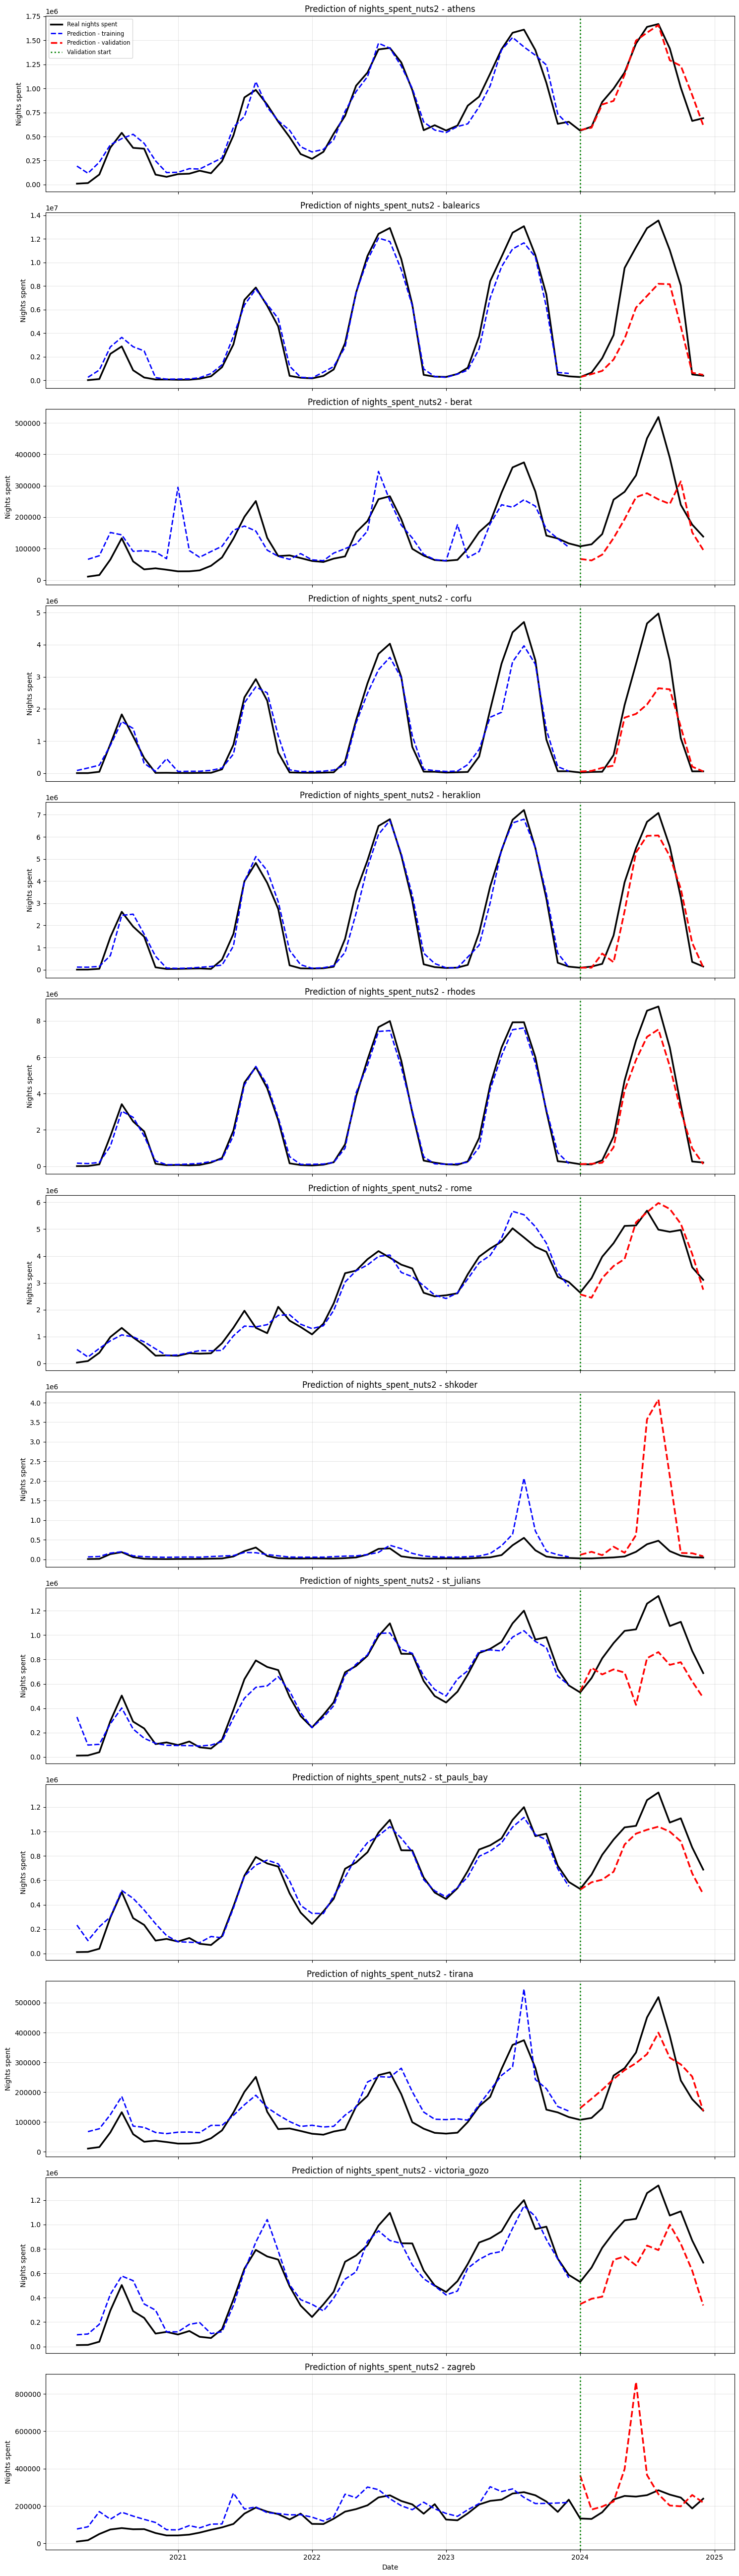

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================================================
# CONFIGURATION
# ============================================================

SELECTED_CITIES = [
    'athens',
    'balearics',
    'berat',
    'corfu',
    'heraklion',
    'mari',
    'rhodes',
    'rome',
    'shkoder',
    'st_julians',
    'st_pauls_bay',
    'tirana',
    'zagreb',
    'victoria_gozo'
]

TARGET = 'nights_spent_nuts2'
VALIDATION_START_DATE = '2024-01-01'

USE_GT_LAGS = True
GT_LAGS = [1, 2, 3]   # Google Trends from previous months

RANDOM_STATE = 42

# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv('master_tourism_dataset.csv')
df['date'] = pd.to_datetime(df['date'])

# Normalize city names
df['city_clean'] = (
    df['city']
    .astype(str)
    .str.lower()
    .str.strip()
)

# Select all Google Trends columns
gt_cols = [col for col in df.columns if col.startswith('gt_')]

print("Google Trends columns used:")
print(gt_cols)

# Fill missing GT values
df[gt_cols] = df[gt_cols].fillna(0)

# Keep only selected cities
df = df[df['city_clean'].isin(SELECTED_CITIES)].copy()

print("\nCities used:")
print(sorted(df['city_clean'].unique()))

# Clean target
df = df.dropna(subset=[TARGET])
df = df[df[TARGET] > 0].copy()

# Sort
df = df.sort_values(['city_clean', 'date'])

# ============================================================
# 2. FEATURE ENGINEERING
# ============================================================

# Month features
df['month'] = df['date'].dt.month

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Optional: year can capture long-term trend
df['year'] = df['date'].dt.year

# Create lagged Google Trends features
if USE_GT_LAGS:
    for col in gt_cols:
        for lag in GT_LAGS:
            df[f'{col}_lag{lag}'] = (
                df
                .groupby('city_clean')[col]
                .shift(lag)
            )

    gt_feature_cols = [
        f'{col}_lag{lag}'
        for col in gt_cols
        for lag in GT_LAGS
    ]

else:
    gt_feature_cols = gt_cols

# Drop rows where GT lags are missing
df_ml = df.dropna(subset=gt_feature_cols).copy()

# Store city for plotting before one-hot encoding
df_ml['orig_city'] = df_ml['city_clean']

# One-hot encode city
df_ml = pd.get_dummies(
    df_ml,
    columns=['city_clean'],
    drop_first=True
)

city_feature_cols = [
    col for col in df_ml.columns
    if col.startswith('city_clean_')
]

# Final feature list
features = (
    gt_feature_cols +
    ['month_sin', 'month_cos', 'year'] +
    city_feature_cols
)

print("\nFeatures used for training:")
for feature in features:
    print(feature)

# ============================================================
# 3. TRAIN / VALIDATION SPLIT
# ============================================================

validation_start = pd.to_datetime(VALIDATION_START_DATE)

train_df = df_ml[df_ml['date'] < validation_start].copy()
val_df = df_ml[df_ml['date'] >= validation_start].copy()

X_train = train_df[features]
y_train = train_df[TARGET]

X_val = val_df[features]
y_val = val_df[TARGET]

print("\nTraining rows:", len(train_df))
print("Validation rows:", len(val_df))

# ============================================================
# 4. TRAIN MODEL
# ============================================================

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model.fit(X_train, y_train)

# ============================================================
# 5. PREDICTIONS AND METRICS
# ============================================================

train_df['prediction'] = model.predict(X_train)
val_df['prediction'] = model.predict(X_val)

train_pred = train_df['prediction']
val_pred = val_df['prediction']

print("\n--- MODEL PERFORMANCE ---")
print(f"Training MAE: {mean_absolute_error(y_train, train_pred):.2f}")
print(f"Training RMSE: {np.sqrt(mean_squared_error(y_train, train_pred)):.2f}")
print(f"Training R2: {r2_score(y_train, train_pred):.4f}")

print(f"\nValidation MAE: {mean_absolute_error(y_val, val_pred):.2f}")
print(f"Validation RMSE: {np.sqrt(mean_squared_error(y_val, val_pred)):.2f}")
print(f"Validation R2: {r2_score(y_val, val_pred):.4f}")

# Combine train and validation for plotting
df_plot = pd.concat([train_df, val_df], axis=0)
df_plot = df_plot.sort_values(['orig_city', 'date'])

# ============================================================
# 6. FEATURE IMPORTANCE
# ============================================================

importances = (
    pd.Series(model.feature_importances_, index=features)
    .sort_values(ascending=False)
)

print("\n--- TOP 20 FEATURES ---")
print(importances.head(20))

# ============================================================
# 7. PLOT REAL DATA VS PREDICTIONS
# ============================================================

cities = sorted(df_plot['orig_city'].unique())

fig, axes = plt.subplots(
    len(cities),
    1,
    figsize=(15, 4 * len(cities)),
    sharex=True
)

if len(cities) == 1:
    axes = [axes]

for i, city in enumerate(cities):
    ax = axes[i]

    city_data = df_plot[df_plot['orig_city'] == city].sort_values('date')

    train_city = city_data[city_data['date'] < validation_start]
    val_city = city_data[city_data['date'] >= validation_start]

    # Real data
    ax.plot(
        city_data['date'],
        city_data[TARGET],
        label='Real nights spent',
        color='black',
        linewidth=2.5
    )

    # Training prediction
    ax.plot(
        train_city['date'],
        train_city['prediction'],
        label='Prediction - training',
        color='blue',
        linestyle='--',
        linewidth=2
    )

    # Validation prediction
    ax.plot(
        val_city['date'],
        val_city['prediction'],
        label='Prediction - validation',
        color='red',
        linestyle='--',
        linewidth=2.5
    )

    # Validation split line
    ax.axvline(
        validation_start,
        color='green',
        linestyle=':',
        linewidth=2,
        label='Validation start'
    )

    ax.set_title(f"Prediction of nights_spent_nuts2 - {city}")
    ax.set_ylabel("Nights spent")
    ax.grid(True, alpha=0.3)

    if i == 0:
        ax.legend(loc='upper left', fontsize='small')

plt.xlabel("Date")
plt.tight_layout()
plt.show()

In [14]:
import pandas as pd

df = pd.read_csv('master_tourism_dataset.csv')

df.head(80)

,date,country,region,county,city,gt_airbnb,gt_hotel,gt_flights,gt_attraction_1,gt_attraction_2,gt_attraction_3,nights_spent_nuts2,nights_spent_country,arrivals_country,bed_places_country,avg_length_of_stay_country,occupancy_rate_country
0,2020-01-01,Albania,Qendror (Central),Berat County,berat,0,32,0,11,0,0.0,60094.0,96566.0,52724.0,NaN,1.83,NaN
1,2020-02-01,Albania,Qendror (Central),Berat County,berat,0,16,0,0,0,0.0,32163.0,63781.0,45356.0,NaN,1.41,NaN
2,2020-03-01,Albania,Qendror (Central),Berat County,berat,0,0,0,0,0,0.0,9072.0,17009.0,12171.0,NaN,1.40,NaN
3,2020-04-01,Albania,Qendror (Central),Berat County,berat,0,0,0,0,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
4,2020-05-01,Albania,Qendror (Central),Berat County,berat,0,0,0,0,0,0.0,10772.0,38098.0,11803.0,NaN,3.23,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,2020-01-01,Albania,Jugor (Southern),Gjirokastër County,gjirokastra,0,15,0,0,0,NaN,21446.0,96566.0,52724.0,NaN,1.83,NaN
76,2020-02-01,Albania,Jugor (Southern),Gjirokastër County,gjirokastra,0,18,0,0,0,NaN,18807.0,63781.0,45356.0,NaN,1.41,NaN
77,2020-03-01,Albania,Jugor (Southern),Gjirokastër County,gjirokastra,0,0,0,0,0,NaN,4696.0,17009.0,12171.0,NaN,1.40,NaN
78,2020-04-01,Albania,Jugor (Southern),Gjirokastër County,gjirokastra,0,0,0,0,0,NaN,0.0,0.0,0.0,NaN,NaN,NaN
